# Imports

In [725]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time
from scipy import stats
from scipy.stats import t, chisquare

# Exercise 1

## Part 1

### Part 1.a

[0.17509572828086925, 0.8642896215624845, 0.7298224675518424, 0.6354865980406783, 0.23979312745536824, 0.0513203043413397, 0.2881794221492864, 0.9221741508777165, 0.9494256303147844, 0.8191357103784375]


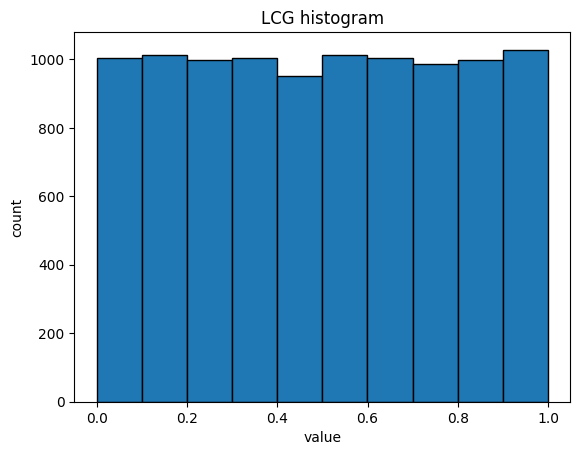

In [726]:
n = 10000
a = 142
b = 14
M = 20109

x = 12345
numbers = []

for i in range(n):
    x = (a * x + b) % M
    u = x / M
    numbers.append(u)

print(numbers[:10])

plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("value")
plt.ylabel("count")
plt.title("LCG histogram")
plt.show()

### Part 1.b

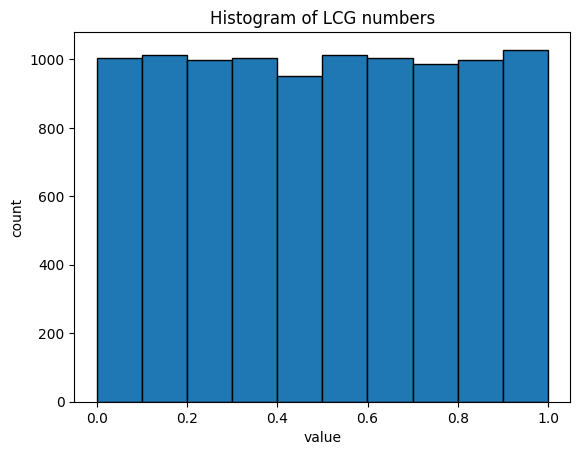

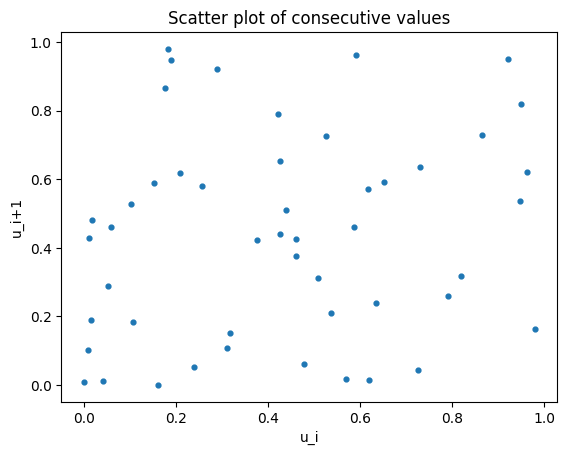

In [727]:
plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("value")
plt.ylabel("count")
plt.title("Histogram of LCG numbers")
plt.show()

plt.scatter(numbers[:49], numbers[1:50], s=12)
plt.xlabel("u_i")
plt.ylabel("u_i+1")
plt.title("Scatter plot of consecutive values")
plt.show()


#### Chi-square test

In [728]:
n = len(numbers)
num_bins = 10
counts = [0] * num_bins

for u in numbers:
    i = int(u * num_bins)

    if i == num_bins:
        i = num_bins - 1
        
    counts[i] += 1

expected = n / num_bins
chi2 = 0

for obs in counts:
    chi2 += (obs - expected)**2 / expected

print("Observed counts:", counts)
print("Expected per bin:", expected)
print("Chi-square value:", chi2)
print("Critical value:", 16.92)

if chi2 < 16.92:
    print("Do not reject uniformity")
else:
    print("Reject uniformity")

Observed counts: [1003, 1013, 999, 1003, 953, 1013, 1006, 985, 999, 1026]
Expected per bin: 1000.0
Chi-square value: 3.5040000000000004
Critical value: 16.92
Do not reject uniformity


#### Kolmogorov-Smirnov test

In [729]:
sorted_vals = sorted(numbers)
biggest_diff = 0

for i in range(n):
    emp = (i + 1) / n
    theo = sorted_vals[i]
    diff = abs(emp - theo)
    
    if diff > biggest_diff:
        biggest_diff = diff

critical = 1.36 / np.sqrt(n)

print("KS statistic:", biggest_diff)
print("Critical value:", critical)

if biggest_diff < critical:
    print("Do not reject uniformity")
else:
    print("Reject uniformity")

KS statistic: 0.004755099706599042
Critical value: 0.013600000000000001
Do not reject uniformity


#### Runs test

In [730]:
labels = []

for u in numbers:
    if u < 0.5:
        labels.append(0)
    else:
        labels.append(1)

num_runs = 1

for i in range(1, n):
    if labels[i] != labels[i - 1]:
        num_runs += 1

n0 = labels.count(0)
n1 = labels.count(1)

exp_runs = 1 + (2 * n0 * n1) / (n0 + n1)
var_runs = (2 * n0 * n1 * (2 * n0 * n1 - n0 - n1)) / ((n0 + n1)**2 * (n0 + n1 - 1))
z = (num_runs - exp_runs) / np.sqrt(var_runs)

print("Runs:", num_runs)
print("Expected:", round(exp_runs, 2))
print("Z-value:", round(z, 4))

if abs(z) < 1.96:
    print("Do not reject independence")
else:
    print("Reject independence")

Runs: 5005
Expected: 5000.83
Z-value: 0.0834
Do not reject independence


#### Correlation test

In [731]:
for h in [1, 2, 5, 10]:
    a_vals = numbers[:-h]
    b_vals = numbers[h:]
    corr = np.corrcoef(a_vals, b_vals)[0, 1]
    print("h =", h, "  correlation =", round(corr, 5))

h = 1   correlation = 0.00945
h = 2   correlation = 0.01334
h = 5   correlation = -0.00227
h = 10   correlation = 0.01795


### Part 1.c

#### Attempt 1 - bad parameters

First 20 values:
[0.001143766472723656, 0.006116664180217813, 0.030981152717688597, 0.15530359540504252, 0.7769158088418121, 0.8849768760256601, 0.4252822119449003, 0.126808891541101, 0.6344422895221046, 0.17260927942712218, 0.8634442289522104, 0.3176189765776518, 0.5884927147048585, 0.9428614053408921, 0.7147048585210602, 0.5739221244219006, 0.8700084539261027, 0.35044010144711324, 0.7525983390521657, 0.763389527077428]


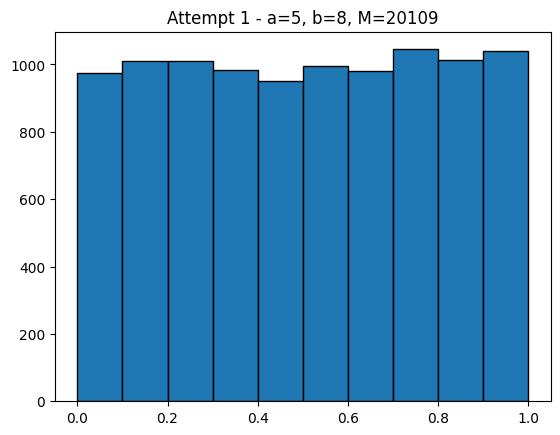

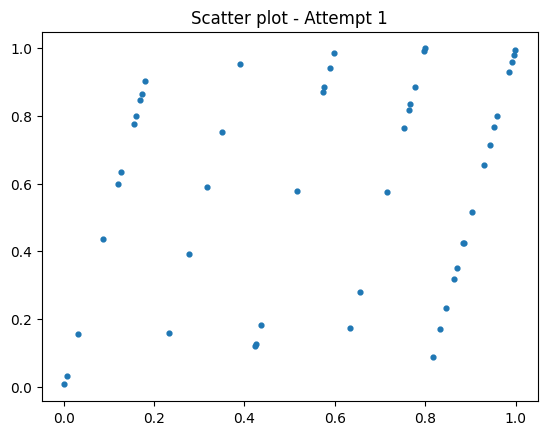

In [732]:
n = 10000
a = 5
b = 8
M = 20109

x = 3
numbers_1 = []

for i in range(n):
    x = (a * x + b) % M
    u = x / M
    numbers_1.append(u)

print("First 20 values:")
print(numbers_1[:20])

plt.hist(numbers_1, bins=10, edgecolor="black")
plt.title("Attempt 1 - a=5, b=8, M=20109")
plt.show()

plt.scatter(numbers_1[:49], numbers_1[1:50], s=12)
plt.title("Scatter plot - Attempt 1")
plt.show()


In [733]:
num_bins = 10
counts = [0] * num_bins

for u in numbers_1:
    i = int(u * num_bins)

    if i == num_bins:
        i = num_bins - 1
        
    counts[i] += 1

expected = n / num_bins
chi2 = 0

for obs in counts:
    chi2 += (obs - expected)**2 / expected

print("Counts:", counts)
print("Chi-square:", round(chi2, 3), "  critical:", 16.92)

sv = sorted(numbers_1)
ks = max(abs((i + 1) / n - sv[i]) for i in range(n))
print("KS value:", round(ks, 5), "  critical:", round(1.36 / np.sqrt(n), 5))

Counts: [973, 1010, 1010, 984, 950, 996, 980, 1045, 1013, 1039]
Chi-square: 7.816   critical: 16.92
KS value: 0.01116   critical: 0.0136


#### Attempt 2 - slightly better

First 20 values:
[0.2060546875, 0.24169921875, 0.048828125, 0.01025390625, 0.6025390625, 0.52099609375, 0.3046875, 0.46142578125, 0.0927734375, 0.01904296875, 0.404296875, 0.88134765625, 0.1767578125, 0.23583984375, 0.84765625, 0.77001953125, 0.3544921875, 0.67138671875, 0.134765625, 0.62744140625]


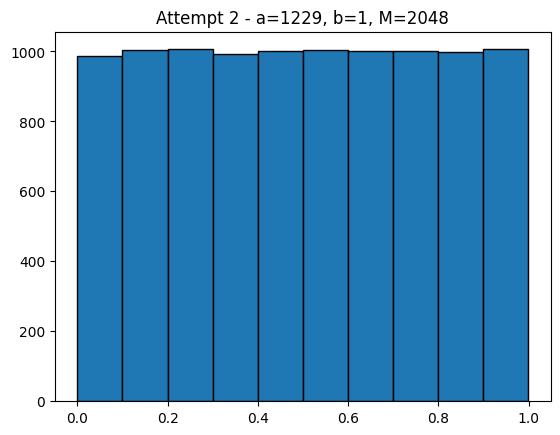

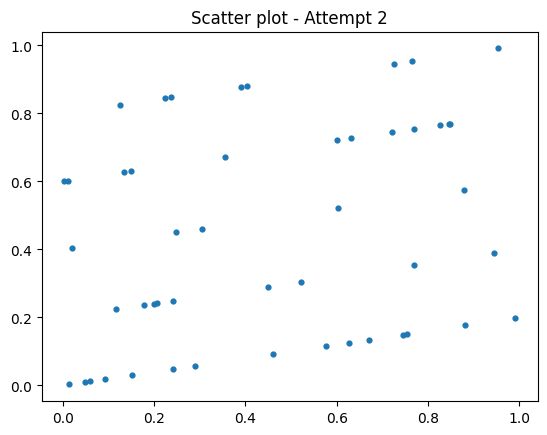

In [734]:
a = 1229
b = 1
M = 2048

x = 12345
numbers_2 = []

for i in range(n):
    x = (a * x + b) % M
    u = x / M
    numbers_2.append(u)

print("First 20 values:")
print(numbers_2[:20])

plt.hist(numbers_2, bins=10, edgecolor="black")
plt.title("Attempt 2 - a=1229, b=1, M=2048")
plt.show()

plt.scatter(numbers_2[:49], numbers_2[1:50], s=12)
plt.title("Scatter plot - Attempt 2")
plt.show()


In [735]:
num_bins = 10
counts = [0] * num_bins

for u in numbers_2:
    i = int(u * num_bins)

    if i == num_bins:
        i = num_bins - 1
        
    counts[i] += 1

expected = n / num_bins
chi2 = 0

for obs in counts:
    chi2 += (obs - expected)**2 / expected

print("Counts:", counts)
print("Chi-square:", round(chi2, 3), "  critical:", 16.92)

sv = sorted(numbers_2)
ks = max(abs((i + 1) / n - sv[i]) for i in range(n))
print("KS value:", round(ks, 5), "  critical:", round(1.36 / np.sqrt(n), 5))

corr = np.corrcoef(numbers_2[:-1], numbers_2[1:])[0, 1]
print("Lag-1 correlation:", round(corr, 5))

Counts: [987, 1003, 1006, 998, 995, 1004, 1006, 1002, 998, 1001]
Chi-square: 0.304   critical: 16.92
KS value: 0.00154   critical: 0.0136
Lag-1 correlation: 0.1957


#### Final generator

First 20 values:
[0.17509572828086925, 0.8642896215624845, 0.7298224675518424, 0.6354865980406783, 0.23979312745536824, 0.0513203043413397, 0.2881794221492864, 0.9221741508777165, 0.9494256303147844, 0.8191357103784375, 0.3179670794171764, 0.15202148291809636, 0.5877467800487344, 0.4607389725993336, 0.42563031478442487, 0.44020090506738274, 0.5092247252474017, 0.31060719081008503, 0.10691730071112437, 0.18295290665871003]


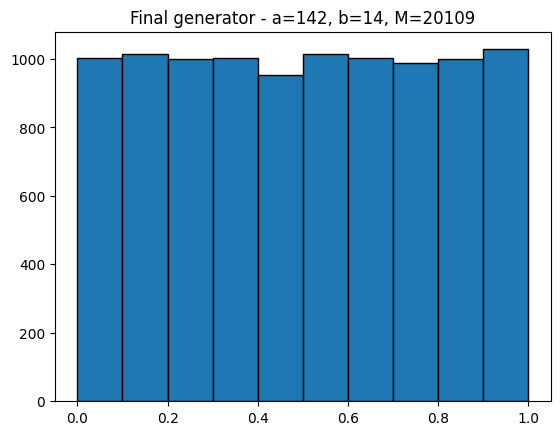

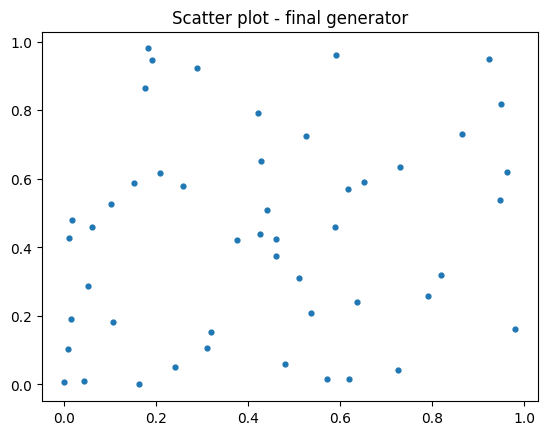

In [736]:
a = 142
b = 14
M = 20109

x = 12345
good_numbers = []

for i in range(n):
    x = (a * x + b) % M
    u = x / M
    good_numbers.append(u)

print("First 20 values:")
print(good_numbers[:20])

plt.hist(good_numbers, bins=10, edgecolor="black")
plt.title("Final generator - a=142, b=14, M=20109")
plt.show()

plt.scatter(good_numbers[:49], good_numbers[1:50], s=12)
plt.title("Scatter plot - final generator")
plt.show()


#### Chi-square test

In [737]:
num_bins = 10
counts = [0] * num_bins

for u in good_numbers:
    i = int(u * num_bins)

    if i == num_bins:
        i = num_bins - 1

    counts[i] += 1

expected = n / num_bins
chi2 = 0

for obs in counts:
    chi2 += (obs - expected)**2 / expected

print("Counts:", counts)
print("Chi-square:", round(chi2, 3))

if chi2 < 16.92:
    print("Do not reject uniformity")
else:
    print("Reject uniformity")

Counts: [1003, 1013, 999, 1003, 953, 1013, 1006, 985, 999, 1026]
Chi-square: 3.504
Do not reject uniformity


#### Kolmogorov-Smirnov test

In [738]:
sv = sorted(good_numbers)
biggest = 0

for i in range(n):
    diff = abs((i + 1) / n - sv[i])

    if diff > biggest:
        biggest = diff

critical = 1.36 / np.sqrt(n)

print("KS value:", round(biggest, 5))
print("Critical value:", round(critical, 5))

if biggest < critical:
    print("Do not reject uniformity")
else:
    print("Reject uniformity")

KS value: 0.00476
Critical value: 0.0136
Do not reject uniformity


#### Runs test

In [739]:
labels = []

for u in good_numbers:
    if u < 0.5:
        labels.append(0)
    else:
        labels.append(1)

num_runs = 1

for i in range(1, n):
    if labels[i] != labels[i - 1]:
        num_runs += 1

n0 = labels.count(0)
n1 = labels.count(1)

exp_runs = 1 + (2 * n0 * n1) / (n0 + n1)
var_runs = (2 * n0 * n1 * (2 * n0 * n1 - n0 - n1)) / ((n0 + n1)**2 * (n0 + n1 - 1))
z = (num_runs - exp_runs) / np.sqrt(var_runs)

print("Runs:", num_runs, "  Expected:", round(exp_runs, 2))
print("Z-value:", round(z, 4))

if abs(z) < 1.96:
    print("Do not reject independence")
else:
    print("Reject independence")

Runs: 5005   Expected: 5000.83
Z-value: 0.0834
Do not reject independence


#### Correlation test

In [740]:
for h in [1, 2, 5, 10]:
    a_vals = good_numbers[:-h]
    b_vals = good_numbers[h:]
    corr = np.corrcoef(a_vals, b_vals)[0, 1]
    print("h =", h, "  correlation =", round(corr, 5))

h = 1   correlation = 0.00945
h = 2   correlation = 0.01334
h = 5   correlation = -0.00227
h = 10   correlation = 0.01795


## Part 2

First 10 values: [0.9296160928171479, 0.3163755545817859, 0.18391881167709445, 0.2045602785530397, 0.5677250290816866, 0.5955447029792516, 0.9645145197356216, 0.6531770968715709, 0.7489066375339118, 0.6535698708517353]


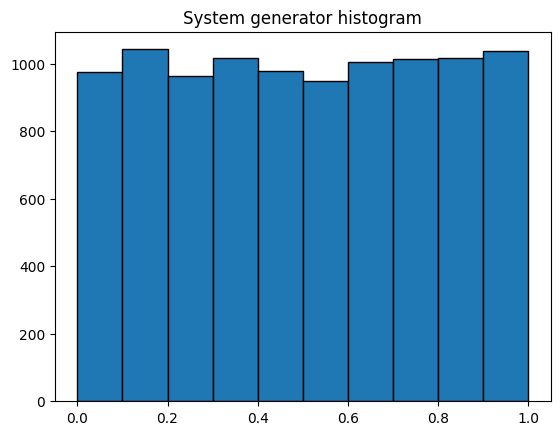

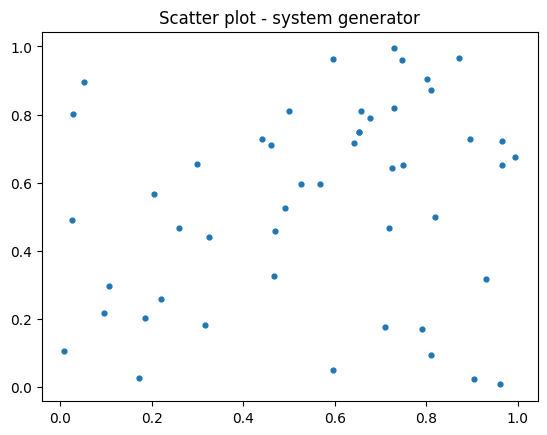

In [741]:
n = 10000
np.random.seed(12345)

sys_numbers = []

for i in range(n):
    sys_numbers.append(np.random.random())

print("First 10 values:", sys_numbers[:10])

plt.hist(sys_numbers, bins=10, edgecolor="black")
plt.title("System generator histogram")
plt.show()

plt.scatter(sys_numbers[:49], sys_numbers[1:50], s=12)
plt.title("Scatter plot - system generator")
plt.show()


#### Chi-square test

In [742]:
num_bins = 10
counts = [0] * num_bins

for u in sys_numbers:
    i = int(u * num_bins)

    if i == num_bins:
        i = num_bins - 1
        
    counts[i] += 1

expected = n / num_bins
chi2 = 0

for obs in counts:
    chi2 += (obs - expected)**2 / expected

print("Counts:", counts)
print("Chi-square:", chi2, "  critical:", 16.92)

if chi2 < 16.92:
    print("Do not reject uniformity")
else:
    print("Reject uniformity")

Counts: [974, 1042, 966, 1016, 980, 948, 1004, 1015, 1016, 1039]
Chi-square: 8.974   critical: 16.92
Do not reject uniformity


#### Kolmogorov-Smirnov test

In [743]:
sorted_vals = sorted(sys_numbers)
biggest_diff = 0

for i in range(n):
    diff = abs((i + 1) / n - sorted_vals[i])

    if diff > biggest_diff:
        biggest_diff = diff

critical = 1.36 / np.sqrt(n)

print("KS value:", biggest_diff)
print("Critical value:", critical)

if biggest_diff < critical:
    print("Do not reject uniformity")
else:
    print("Reject uniformity")

KS value: 0.009214657318046049
Critical value: 0.013600000000000001
Do not reject uniformity


#### Runs test

In [744]:
labels = []

for u in sys_numbers:
    if u < 0.5:
        labels.append(0)
    else:
        labels.append(1)

num_runs = 1

for i in range(1, n):
    if labels[i] != labels[i - 1]:
        num_runs += 1

n0 = labels.count(0)
n1 = labels.count(1)

exp_runs = 1 + (2 * n0 * n1) / (n0 + n1)
var_runs = (2 * n0 * n1 * (2 * n0 * n1 - n0 - n1)) / ((n0 + n1)**2 * (n0 + n1 - 1))
z = (num_runs - exp_runs) / np.sqrt(var_runs)

print("Runs:", num_runs, "  Expected:", round(exp_runs, 2))
print("Z-value:", round(z, 4))

if abs(z) < 1.96:
    print("Do not reject independence")
else:
    print("Reject independence")

Runs: 4991   Expected: 5000.9
Z-value: -0.1981
Do not reject independence


#### Correlation test

In [745]:
for h in [1, 2, 5, 10]:
    a_vals = sys_numbers[:-h]
    b_vals = sys_numbers[h:]
    corr = np.corrcoef(a_vals, b_vals)[0, 1]
    print("h =", h, "  correlation =", round(corr, 5))

h = 1   correlation = 0.00366
h = 2   correlation = -0.01275
h = 5   correlation = -0.00623
h = 10   correlation = -0.00178


## Part 3

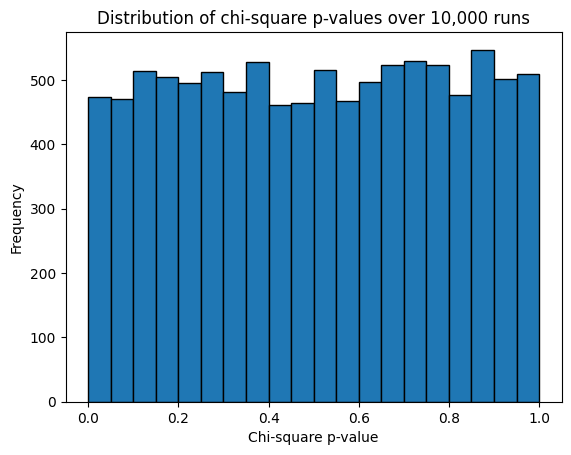

Proportion below 0.05: 0.0474


In [746]:
np.random.seed(12345)
n = 10000
repetitions = 10000
p_values = []

for _ in range(repetitions):
    vals = np.random.random(n)
    counts, _ = np.histogram(vals, bins=10, range=(0, 1))
    _, p_value = stats.chisquare(counts)
    p_values.append(p_value)

plt.hist(p_values, bins=20, edgecolor="black")
plt.xlabel("Chi-square p-value")
plt.ylabel("Frequency")
plt.title("Distribution of chi-square p-values over 10,000 runs")
plt.show()

print("Proportion below 0.05:", round(np.mean(np.array(p_values) < 0.05), 4))

# Exercise 2


## Part 1


p = 0.05 simulated mean = 20.2762 theoretical mean = 20.0
   simulated variance = 384.4026 theoretical variance = 380.0


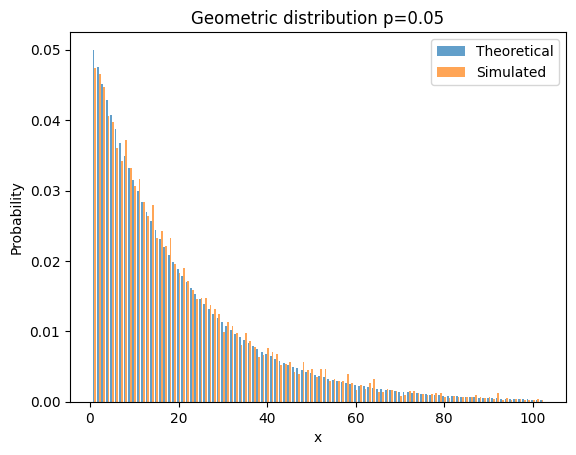

p = 0.05   chi-square: 90.4795   critical: 125.4584
  Do not reject
p = 0.5 simulated mean = 1.9849 theoretical mean = 2.0
   simulated variance = 1.9549 theoretical variance = 2.0


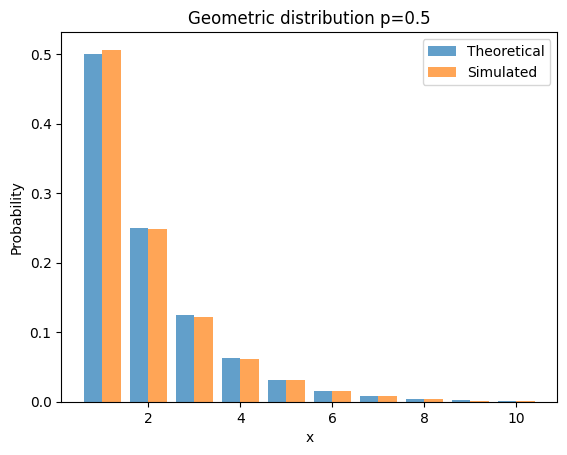

p = 0.5   chi-square: 4.4016   critical: 16.919
  Do not reject
p = 0.95 simulated mean = 1.0504 theoretical mean = 1.0526
   simulated variance = 0.0527 theoretical variance = 0.0554


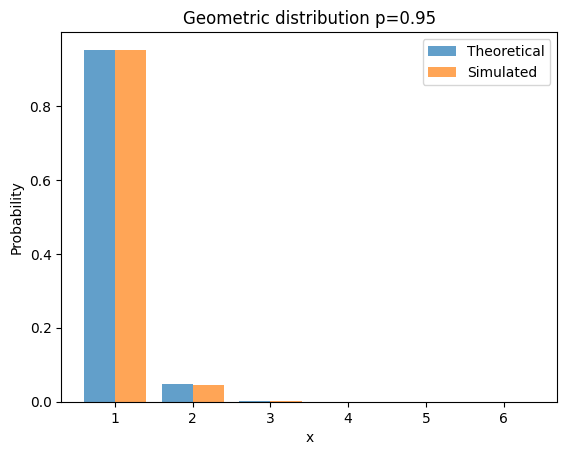

p = 0.95   chi-square: 2.4003   critical: 11.0705
  Do not reject


In [747]:
np.random.seed(42)

n = 10000

for p in [0.05, 0.5, 0.95]:
    geom_samples = []
    for _ in range(n):
        u = np.random.random()
        x = int(np.log(u) / np.log(1 - p)) + 1
        geom_samples.append(x)

    x_vals = list(range(1, int(sum(geom_samples) / n * 5) + 2))
    simulated = [geom_samples.count(x) / n for x in x_vals]
    sim_mean = np.mean(geom_samples)
    sim_var = np.var(geom_samples, ddof=1)
    print("p =", p, "simulated mean =", round(sim_mean, 4), "theoretical mean =", round(1 / p, 4))
    print("   simulated variance =", round(sim_var, 4), "theoretical variance =", round((1 - p) / p**2, 4))
    theoretical = [(1 - p)**(x - 1) * p for x in x_vals]

    plt.bar([x - 0.2 for x in x_vals], theoretical, width=0.4, label="Theoretical", alpha=0.7)
    plt.bar([x + 0.2 for x in x_vals], simulated, width=0.4, label="Simulated", alpha=0.7)
    plt.xlabel("x")
    plt.ylabel("Probability")
    plt.title("Geometric distribution p=" + str(p))
    plt.legend()
    plt.show()

    chi2 = 0
    for x in x_vals:
        obs = geom_samples.count(x)
        exp = n * (1 - p)**(x - 1) * p
        if exp > 0:
            chi2 += (obs - exp)**2 / exp
    critical = stats.chi2.ppf(0.95, df=len(x_vals) - 1)
    print("p =", p, "  chi-square:", round(chi2, 4), "  critical:", round(critical, 4))
    if chi2 < critical:
        print("  Do not reject")
    else:
        print("  Reject")


## Part 2


In [748]:
np.random.seed(42)

probs = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]
values = [1, 2, 3, 4, 5, 6]
n = 10000

cum = []
total = 0
for p in probs:
    total += p
    cum.append(total)

direct_samples = []

for _ in range(n):
    u = np.random.random()
    for i in range(len(cum)):
        if u <= cum[i]:
            direct_samples.append(values[i])
            break

print("First 10 samples:", direct_samples[:10])

First 10 samples: [3, 6, 6, 5, 2, 2, 1, 6, 5, 6]


In [749]:
max_prob = max(probs)

rejection_samples = []

while len(rejection_samples) < n:
    u1 = np.random.random()
    idx = int(u1 * len(probs))
    u2 = np.random.random()
    if u2 <= probs[idx] / max_prob:
        rejection_samples.append(values[idx])

print("First 10 samples:", rejection_samples[:10])

First 10 samples: [3, 5, 6, 6, 4, 1, 1, 2, 6, 5]


In [750]:
k = len(probs)
F = [p * k for p in probs]
L = list(range(k))

small = [i for i in range(k) if F[i] < 1]
large = [i for i in range(k) if F[i] >= 1]

while small and large:
    s = small.pop(0)
    l = large[0]
    L[s] = l
    F[l] = F[l] - (1 - F[s])
    if F[l] < 1:
        large.pop(0)
        small.append(l)

alias_samples = []

for _ in range(n):
    u1 = np.random.random()
    u2 = np.random.random()
    idx = int(u1 * k)
    if u2 <= F[idx]:
        alias_samples.append(values[idx])
    else:
        alias_samples.append(values[L[idx]])

print("First 10 samples:", alias_samples[:10])

First 10 samples: [6, 5, 5, 5, 5, 1, 5, 6, 5, 6]


In [751]:
for label, sample in [("Direct", direct_samples), ("Rejection", rejection_samples), ("Alias", alias_samples)]:
    sim_probs = [sample.count(v) / n for v in values]

    chi2 = 0
    for i in range(len(values)):
        obs = sample.count(values[i])
        exp = n * probs[i]
        chi2 += (obs - exp)**2 / exp

    critical = stats.chi2.ppf(0.95, df=len(values) - 1)
    p_value = stats.chi2.sf(chi2, df=len(values) - 1)
    print(label, "- chi-square:", round(chi2, 4), "p-value:", round(p_value, 4), "critical:", round(critical, 4))

    if chi2 < critical:
        print("  Do not reject")
    else:
        print("  Reject")

Direct - chi-square: 5.8006 p-value: 0.3261 critical: 11.0705
  Do not reject
Rejection - chi-square: 3.134 p-value: 0.6793 critical: 11.0705
  Do not reject
Alias - chi-square: 5.4954 p-value: 0.3585 critical: 11.0705
  Do not reject


## Part 3


In [752]:
n_big = 100000

start = time.time()
for _ in range(n_big):
    u = np.random.random()
    for i in range(len(cum)):
        if u <= cum[i]:
            break
direct_time = time.time() - start

start = time.time()
count = 0
while count < n_big:
    u1 = np.random.random()
    idx = int(u1 * len(probs))
    u2 = np.random.random()
    if u2 <= probs[idx] / max_prob:
        count += 1
rejection_time = time.time() - start

start = time.time()
for _ in range(n_big):
    u1 = np.random.random()
    u2 = np.random.random()
    idx = int(u1 * k)
    if u2 > F[idx]:
        idx = L[idx]
alias_time = time.time() - start

print("Direct time:   ", round(direct_time, 4), "s")
print("Rejection time:", round(rejection_time, 4), "s")
print("Alias time:    ", round(alias_time, 4), "s")

Direct time:    0.0322 s
Rejection time: 0.0686 s
Alias time:     0.0327 s


In [753]:
for label, sample in [("Direct", direct_samples), ("Rejection", rejection_samples), ("Alias", alias_samples)]:
    chi2 = 0
    for j in range(len(values)):
        obs = sample.count(values[j])
        exp = n * probs[j]
        chi2 += (obs - exp)**2 / exp
    critical = stats.chi2.ppf(0.95, df=len(values) - 1)
    p_value = stats.chi2.sf(chi2, df=len(values) - 1)
    print(label, "chi-square:", round(chi2, 4), "p-value:", round(p_value, 4), "critical:", round(critical, 4))
    if chi2 < critical:
        print("  Do not reject")
    else:
        print("  Reject")

Direct chi-square: 5.8006 p-value: 0.3261 critical: 11.0705
  Do not reject
Rejection chi-square: 3.134 p-value: 0.6793 critical: 11.0705
  Do not reject
Alias chi-square: 5.4954 p-value: 0.3585 critical: 11.0705
  Do not reject


## Part 4


# Exercise 3


## Part 1


### Exponential distribution


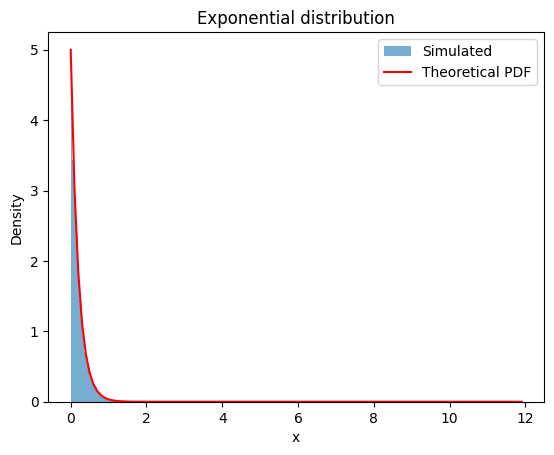

In [754]:
np.random.seed(42)

n = 10000
rate = 5

exp_samples = []

for _ in range(n):
    u = np.random.random()
    exp_samples.append(-np.log(u) / rate)

x_vals = [i * 0.1 for i in range(120)]
pdf_vals = [rate * np.exp(-rate * x) for x in x_vals]

plt.hist(exp_samples, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x_vals, pdf_vals, 'r-', label="Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Exponential distribution")
plt.legend()
plt.show()

### Normal distribution - Box-Muller


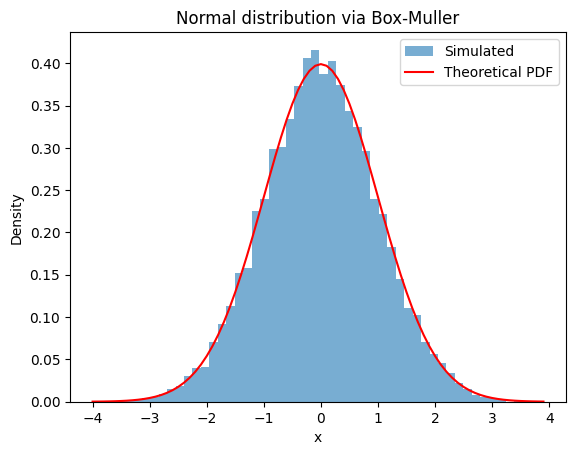

In [755]:
def box_muller_normals(U1, U2):
    radius = np.sqrt(-2 * np.log(U1))
    angle = 2 * np.pi * U2
    return radius * np.cos(angle), radius * np.sin(angle)

U1 = np.random.uniform(0, 1, n)
U2 = np.random.uniform(0, 1, n)
Z0, Z1 = box_muller_normals(U1, U2)

x_vals = [i * 0.1 - 4 for i in range(80)]
pdf_vals = [(1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2) for x in x_vals]

plt.hist(list(Z0) + list(Z1), bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x_vals, pdf_vals, 'r-', label="Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Normal distribution via Box-Muller")
plt.legend()
plt.show()

### Pareto distribution


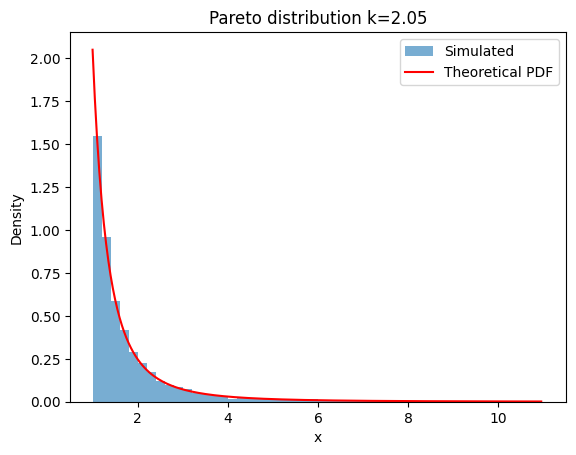

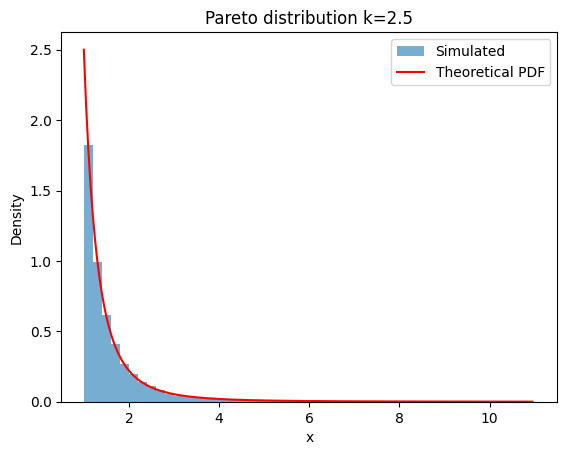

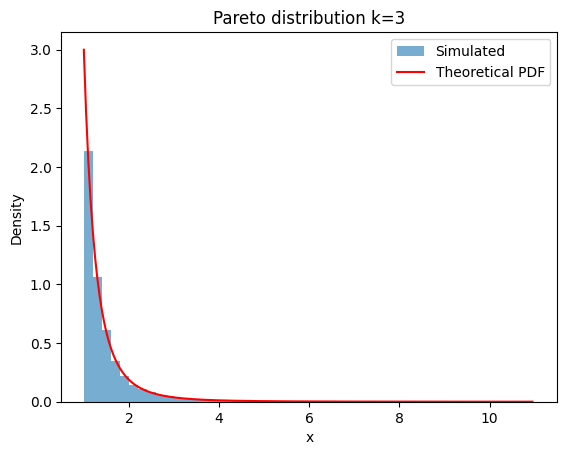

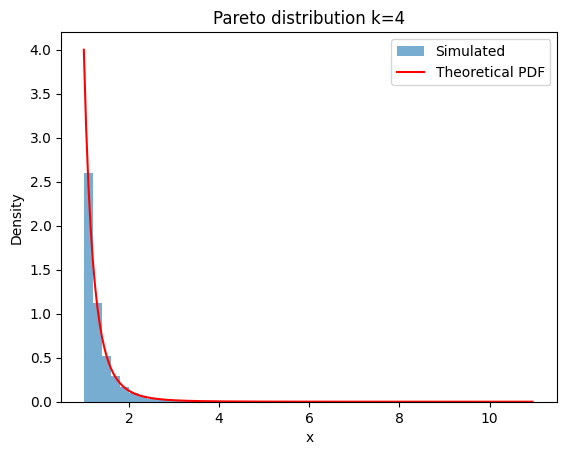

In [756]:
beta = 1
k_values = [2.05, 2.5, 3, 4]

for k in k_values:
    pareto_samples = []

    for _ in range(n):
        u = np.random.random()
        pareto_samples.append(beta * u**(-1.0 / k))

    x_plot = [beta + i * 0.05 for i in range(200)]
    pdf_plot = [k * beta**k / x**(k + 1) for x in x_plot]

    plt.hist(pareto_samples, bins=50, density=True, alpha=0.6, range=(beta, beta + 10), label="Simulated")
    plt.plot(x_plot, pdf_plot, 'r-', label="Theoretical PDF")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Pareto distribution k=" + str(k))
    plt.legend()
    plt.show()

## Part 2


In [757]:
beta = 1
k_values = [2.05, 2.5, 3, 4]

for k in k_values:
    theoretical_mean = beta * k / (k - 1)
    print("k =", k, "  theoretical mean =", round(theoretical_mean, 4))

k = 2.05   theoretical mean = 1.9524
k = 2.5   theoretical mean = 1.6667
k = 3   theoretical mean = 1.5
k = 4   theoretical mean = 1.3333


In [758]:
for k in k_values:
    samples = []
    for _ in range(n):
        u = np.random.random()
        samples.append(beta * u**(-1.0 / k))
    print("k =", k, "  sample mean =", round(sum(samples) / n, 4))

k = 2.05   sample mean = 1.9436
k = 2.5   sample mean = 1.6709
k = 3   sample mean = 1.509
k = 4   sample mean = 1.3335


In [759]:
for k in k_values:
    if k > 2:
        theoretical_var = beta**2 * k / ((k - 1)**2 * (k - 2))
        print("k =", k, "  theoretical variance =", round(theoretical_var, 4))
    else:
        print("k =", k, "  variance undefined (k <= 2)")

k = 2.05   theoretical variance = 37.1882
k = 2.5   theoretical variance = 2.2222
k = 3   theoretical variance = 0.75
k = 4   theoretical variance = 0.2222


In [760]:
for k in k_values:
    samples = []
    for _ in range(n):
        u = np.random.random()
        samples.append(beta * u**(-1.0 / k))
    mean_s = sum(samples) / n
    var_s = sum((x - mean_s)**2 for x in samples) / n
    print("k =", k, "  sample variance =", round(var_s, 4))

k = 2.05   sample variance = 8.1919
k = 2.5   sample variance = 1.8791
k = 3   sample variance = 0.6722
k = 4   sample variance = 0.2221


## Part 3


In [761]:
mu_true = 0
sigma_true = 1
n = 10
n_intervals = 100
alpha = 0.05

t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
chi2_lo = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_hi = stats.chi2.ppf(1 - alpha / 2, df=n - 1)

print("t critical value:    ", round(t_crit, 4))
print("chi2 lower critical: ", round(chi2_lo, 4))
print("chi2 upper critical: ", round(chi2_hi, 4))

t critical value:     2.2622
chi2 lower critical:  2.7004
chi2 upper critical:  19.0228


In [762]:
np.random.seed(42)

mean_covers = 0
var_covers = 0

mean_lower_all = []
mean_upper_all = []
var_lower_all = []
var_upper_all = []

for _ in range(n_intervals):
    U1 = np.random.uniform(0, 1, n)
    U2 = np.random.uniform(0, 1, n)
    sample = [np.sqrt(-2 * np.log(U1[i])) * np.cos(2 * np.pi * U2[i]) for i in range(n)]

    sample_mean = sum(sample) / n
    sample_var = sum((x - sample_mean)**2 for x in sample) / (n - 1)
    sample_sd = sample_var**0.5

    mean_lo = sample_mean - t_crit * sample_sd / n**0.5
    mean_hi = sample_mean + t_crit * sample_sd / n**0.5

    var_lo = (n - 1) * sample_var / chi2_hi
    var_hi = (n - 1) * sample_var / chi2_lo

    mean_lower_all.append(mean_lo)
    mean_upper_all.append(mean_hi)
    var_lower_all.append(var_lo)
    var_upper_all.append(var_hi)

    if mean_lo <= mu_true <= mean_hi:
        mean_covers += 1

    if var_lo <= sigma_true**2 <= var_hi:
        var_covers += 1

print("Mean CI coverage:    ", mean_covers / n_intervals)
print("Variance CI coverage:", var_covers / n_intervals)

Mean CI coverage:     0.95
Variance CI coverage: 1.0


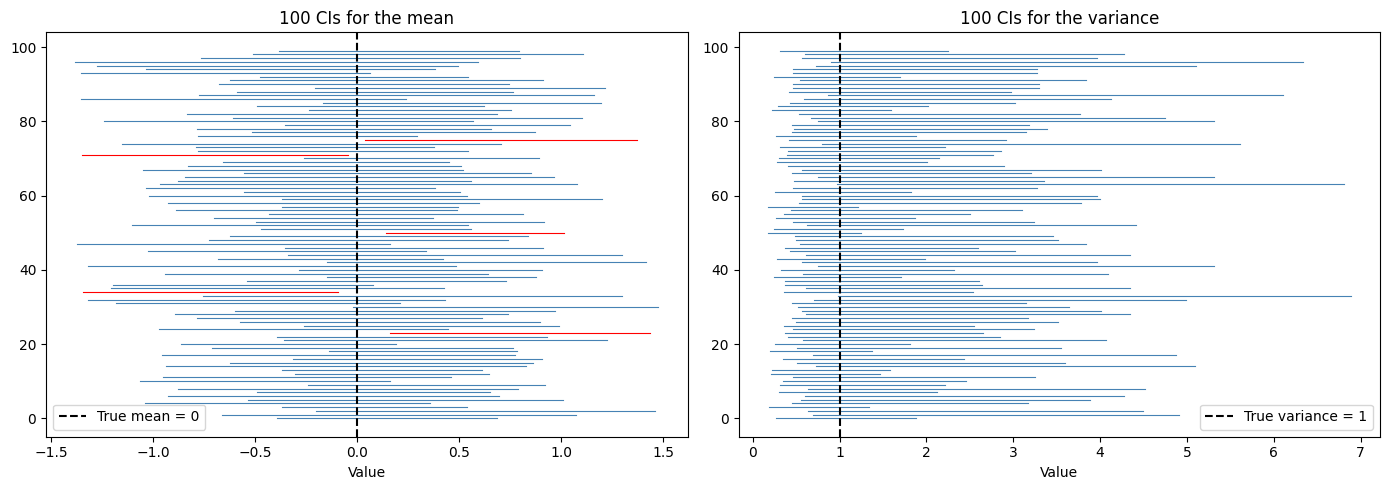

In [763]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for i in range(n_intervals):
    color = 'steelblue' if mean_lower_all[i] <= mu_true <= mean_upper_all[i] else 'red'
    plt.plot([mean_lower_all[i], mean_upper_all[i]], [i, i], color=color, linewidth=0.8)
plt.axvline(mu_true, color='black', linestyle='--', label='True mean = 0')
plt.title("100 CIs for the mean")
plt.xlabel("Value")
plt.legend()

plt.subplot(1, 2, 2)
for i in range(n_intervals):
    color = 'steelblue' if var_lower_all[i] <= sigma_true**2 <= var_upper_all[i] else 'red'
    plt.plot([var_lower_all[i], var_upper_all[i]], [i, i], color=color, linewidth=0.8)
plt.axvline(sigma_true**2, color='black', linestyle='--', label='True variance = 1')
plt.title("100 CIs for the variance")
plt.xlabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

## Part 4


In [764]:
np.random.seed(42)
beta = 1
n = 10000

print(f"{'k':<6} {'Method':<14} {'Sample mean':<14} {'Theory mean':<14} {'Sample variance':<18} {'Theory variance':<16} {'KS p-value':<12}")

for k in k_values:
    direct_samples = beta * np.random.random(n)**(-1.0 / k)

    y = np.random.gamma(shape=k, scale=1.0, size=n)
    composition_samples = beta + np.random.exponential(scale=beta / y)

    theory_mean = beta * k / (k - 1)
    theory_var = beta**2 * k / ((k - 1)**2 * (k - 2))

    for label, samples in [("Direct", direct_samples), ("Composition", composition_samples)]:
        ks_p = stats.kstest(samples, "pareto", args=(k, 0, beta)).pvalue
        print(f"{k:<6} {label:<14} {np.mean(samples):<14.4f} {theory_mean:<14.4f} {np.var(samples, ddof=1):<18.4f} {theory_var:<16.4f} {ks_p:<12.4f}")

k      Method         Sample mean    Theory mean    Sample variance    Theory variance  KS p-value  
2.05   Direct         1.9999         1.9524         15.4829            37.1882          0.0859      
2.05   Composition    1.8986         1.9524         4.5556             37.1882          0.2216      
2.5    Direct         1.6776         1.6667         1.8185             2.2222           0.6905      
2.5    Composition    1.6636         1.6667         1.4890             2.2222           0.3400      
3      Direct         1.5148         1.5000         0.7059             0.7500           0.0548      
3      Composition    1.4852         1.5000         0.7057             0.7500           0.3249      
4      Direct         1.3273         1.3333         0.2105             0.2222           0.5300      
4      Composition    1.3335         1.3333         0.2019             0.2222           0.4871      


# Exercise 4

## Part 1

In [765]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_ia  = 1
mean_svc = 8

results = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u = np.random.random()
        now += -np.log(u) * mean_ia

        u = np.random.random()
        svc = -np.log(u) * mean_svc

        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results.append(blocked / n)

mean_b = sum(results) / reps
variance = sum((r - mean_b)**2 for r in results) / (reps - 1)
sd = variance**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5

A = mean_svc / mean_ia
top = A**m / math.factorial(m)
bot = sum(A**i / math.factorial(i) for i in range(m + 1))
exact = top / bot

print("Blocking fractions:", results)
print("Mean:", round(mean_b, 5))
print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")
print("Erlang-B exact:", round(exact, 5))

Blocking fractions: [0.1147, 0.1236, 0.1232, 0.1206, 0.1179, 0.1192, 0.1126, 0.1314, 0.1154, 0.1192]
Mean: 0.11978
95% CI: ( 0.11591 , 0.12365 )
Erlang-B exact: 0.12166


## Part 2


## Part 2.a


In [766]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_svc = 8

results = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u1 = np.random.random()
        u2 = np.random.random()
        now += -np.log(u1) * 0.5 + -np.log(u2) * 0.5

        u = np.random.random()
        svc = -np.log(u) * mean_svc

        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results.append(blocked / n)

mean_b = sum(results) / reps
sd = (sum((r - mean_b)**2 for r in results) / (reps - 1))**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5

print("Blocking fractions:", results)
print("Mean:", round(mean_b, 5))
print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")

Blocking fractions: [0.0953, 0.0913, 0.0911, 0.1016, 0.0956, 0.0845, 0.0907, 0.0922, 0.092, 0.0945]
Mean: 0.09288
95% CI: ( 0.08974 , 0.09602 )


### Erlang-5 inter-arrival


In [767]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_svc = 8

results = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u1 = np.random.random()
        u2 = np.random.random()
        u3 = np.random.random()
        u4 = np.random.random()
        u5 = np.random.random()
        now += -np.log(u1) * 0.2 + -np.log(u2) * 0.2 + -np.log(u3) * 0.2 + -np.log(u4) * 0.2 + -np.log(u5) * 0.2

        u = np.random.random()
        svc = -np.log(u) * mean_svc

        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results.append(blocked / n)

mean_b = sum(results) / reps
sd = (sum((r - mean_b)**2 for r in results) / (reps - 1))**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5

print("Erlang-5 inter-arrival")
print("Blocking fractions:", results)
print("Mean:", round(mean_b, 5))
print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")

Erlang-5 inter-arrival
Blocking fractions: [0.0734, 0.0778, 0.0714, 0.0669, 0.0706, 0.0747, 0.0691, 0.0719, 0.0713, 0.0786]
Mean: 0.07257
95% CI: ( 0.06995 , 0.07519 )


## Part 2.b


In [768]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_svc = 8

p1 = 0.8; lam1 = 0.8333
p2 = 0.2; lam2 = 5.0

results = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u = np.random.random()
        if u < p1:
            v = np.random.random()
            ia = -np.log(v) / lam1
        else:
            v = np.random.random()
            ia = -np.log(v) / lam2
        now += ia

        u = np.random.random()
        svc = -np.log(u) * mean_svc

        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results.append(blocked / n)

mean_b = sum(results) / reps
sd = (sum((r - mean_b)**2 for r in results) / (reps - 1))**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5

print("Blocking fractions:", results)
print("Mean:", round(mean_b, 5))
print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")

Blocking fractions: [0.1432, 0.1334, 0.1406, 0.1499, 0.1486, 0.1264, 0.1352, 0.1341, 0.1377, 0.1434]
Mean: 0.13925
95% CI: ( 0.13402 , 0.14448 )


## Part 3

### Part 3.a

In [769]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_ia  = 1
svc_time = 8

results = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u = np.random.random()
        now += -np.log(u) * mean_ia

        svc = svc_time

        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results.append(blocked / n)

mean_b = sum(results) / reps
sd = (sum((r - mean_b)**2 for r in results) / (reps - 1))**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5

A = svc_time / mean_ia
top = A**m / math.factorial(m)
bot = sum(A**i / math.factorial(i) for i in range(m + 1))
exact = top / bot

print("Blocking fractions:", results)
print("Mean:", round(mean_b, 5))
print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")
print("Erlang-B exact:", round(exact, 5))

Blocking fractions: [0.1219, 0.1236, 0.1178, 0.1228, 0.123, 0.1222, 0.114, 0.1249, 0.1208, 0.1231]
Mean: 0.12141
95% CI: ( 0.1191 , 0.12372 )
Erlang-B exact: 0.12166


### Part 3.b

In [770]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_ia  = 1
mean_svc = 8

for k in [1.05, 2.05]:
    xm = mean_svc * (k - 1) / k

    results = []

    for rep in range(reps):
        free_at = [0.0] * m
        blocked = 0
        now = 0.0

        for _ in range(n):
            u = np.random.random()
            now += -np.log(u) * mean_ia

            u = np.random.random()
            svc = xm * u**(-1.0 / k)

            earliest = min(free_at)
            idx = free_at.index(earliest)

            if earliest <= now:
                free_at[idx] = now + svc
            else:
                blocked += 1

        results.append(blocked / n)

    mean_b = sum(results) / reps
    sd = (sum((r - mean_b)**2 for r in results) / (reps - 1))**0.5
    t_crit = stats.t.ppf(0.975, df=reps - 1)
    margin = t_crit * sd / reps**0.5

    print("k =", k)
    print("Blocking fractions:", results)
    print("Mean:", round(mean_b, 5))
    print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")
    print()

k = 1.05
Blocking fractions: [0.0001, 0.0016, 0.002, 0.0003, 0.004, 0.0014, 0.0003, 0.0012, 0.0005, 0.0018]
Mean: 0.00132
95% CI: ( 0.00049 , 0.00215 )

k = 2.05
Blocking fractions: [0.1162, 0.1244, 0.108, 0.1302, 0.1214, 0.1293, 0.1359, 0.1119, 0.1341, 0.1196]
Mean: 0.1231
95% CI: ( 0.11639 , 0.12981 )



### Part 3.c

In [771]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_ia  = 1
mean_svc = 8

t_crit = stats.t.ppf(0.975, df=reps - 1)

results_u = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u = np.random.random()
        now += -np.log(u) * mean_ia
        u = np.random.random()
        svc = 4 + u * 8
        earliest = min(free_at)
        idx = free_at.index(earliest)
        
        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results_u.append(blocked / n)

mean_u = sum(results_u) / reps
sd_u = (sum((r - mean_u)**2 for r in results_u) / (reps - 1))**0.5
mg_u = t_crit * sd_u / reps**0.5

print("Uniform(4, 12) service")
print("Blocking fractions:", results_u)
print("Mean:", round(mean_u, 5))
print("95% CI: (", round(mean_u - mg_u, 5), ",", round(mean_u + mg_u, 5), ")")
print()

results_g = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u = np.random.random()
        now += -np.log(u) * mean_ia
        u1 = np.random.random()
        u2 = np.random.random()
        svc = -np.log(u1) * 4 + -np.log(u2) * 4
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1
    results_g.append(blocked / n)

mean_g = sum(results_g) / reps
sd_g = (sum((r - mean_g)**2 for r in results_g) / (reps - 1))**0.5
mg_g = t_crit * sd_g / reps**0.5

print("Gamma(shape=2, scale=4) service")
print("Blocking fractions:", results_g)
print("Mean:", round(mean_g, 5))
print("95% CI: (", round(mean_g - mg_g, 5), ",", round(mean_g + mg_g, 5), ")")
print()

A = mean_svc / mean_ia
top = A**m / math.factorial(m)
bot = sum(A**i / math.factorial(i) for i in range(m + 1))
print("Erlang-B reference:", round(top / bot, 5))

Uniform(4, 12) service
Blocking fractions: [0.1247, 0.1235, 0.1199, 0.1208, 0.1181, 0.1206, 0.1167, 0.1296, 0.1215, 0.1162]
Mean: 0.12116
95% CI: ( 0.11829 , 0.12403 )

Gamma(shape=2, scale=4) service
Blocking fractions: [0.1295, 0.119, 0.1266, 0.1186, 0.124, 0.1237, 0.1232, 0.1248, 0.1147, 0.1214]
Mean: 0.12255
95% CI: ( 0.11949 , 0.12561 )

Erlang-B reference: 0.12166


### Lognormal service


In [772]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_ia  = 1
mean_svc = 8
sigma = 1.0
mu_ln = np.log(mean_svc) - sigma**2 / 2

t_crit = stats.t.ppf(0.975, df=reps - 1)
results_ln = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        u = np.random.random()
        now += -np.log(u) * mean_ia
        u1 = np.random.random()
        u2 = np.random.random()
        z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
        svc = np.exp(mu_ln + sigma * z)
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results_ln.append(blocked / n)

mean_ln = sum(results_ln) / reps
sd_ln = (sum((r - mean_ln)**2 for r in results_ln) / (reps - 1))**0.5
mg_ln = t_crit * sd_ln / reps**0.5

print("Lognormal(sigma=1) service")
print("Blocking fractions:", results_ln)
print("Mean:", round(mean_ln, 5))
print("95% CI: (", round(mean_ln - mg_ln, 5), ",", round(mean_ln + mg_ln, 5), ")")

Lognormal(sigma=1) service
Blocking fractions: [0.1266, 0.1262, 0.1208, 0.118, 0.1242, 0.1115, 0.1254, 0.1317, 0.1115, 0.1316]
Mean: 0.12275
95% CI: ( 0.11756 , 0.12794 )


## Part 5

In [773]:
np.random.seed(12345)

m = 10
n = 10000
reps = 10
mean_ia  = 1
mean_svc = 8
t_crit = stats.t.ppf(0.975, df=reps - 1)

def run(get_ia, get_svc):
    res = []
    for rep in range(reps):
        free_at = [0.0] * m
        blocked = 0
        now = 0.0
        for _ in range(n):
            now += get_ia()
            svc = get_svc()
            earliest = min(free_at)
            idx = free_at.index(earliest)
            if earliest <= now:
                free_at[idx] = now + svc
            else:
                blocked += 1
        res.append(blocked / n)
    mean_b = sum(res) / reps
    sd = (sum((r - mean_b)**2 for r in res) / (reps - 1))**0.5
    margin = t_crit * sd / reps**0.5
    return mean_b, mean_b - margin, mean_b + margin

mu_ln_summary = np.log(mean_svc) - 0.5

p1 = 0.8; lam1 = 0.8333
p2 = 0.2; lam2 = 5.0

scenarios = [
    ("Part 1  - Poisson / Exp",          lambda: -np.log(np.random.random()) * mean_ia,  lambda: -np.log(np.random.random()) * mean_svc),
    ("Part 2a - Erlang-2 / Exp",         lambda: -np.log(np.random.random()) * 0.5 + -np.log(np.random.random()) * 0.5, lambda: -np.log(np.random.random()) * mean_svc),
    ("Part 2a - Erlang-5 / Exp",         lambda: sum(-np.log(np.random.random()) * 0.2 for _ in range(5)), lambda: -np.log(np.random.random()) * mean_svc),
    ("Part 2b - HyperExp / Exp",         lambda: -np.log(np.random.random()) / lam1 if np.random.random() < p1 else -np.log(np.random.random()) / lam2, lambda: -np.log(np.random.random()) * mean_svc),
    ("Part 3a - Poisson / Constant",     lambda: -np.log(np.random.random()) * mean_ia,  lambda: mean_svc),
    ("Part 3b - Pareto k=1.05",          lambda: -np.log(np.random.random()) * mean_ia,  lambda: mean_svc * (1.05 - 1) / 1.05 * np.random.random()**(-1.0 / 1.05)),
    ("Part 3b - Pareto k=2.05",          lambda: -np.log(np.random.random()) * mean_ia,  lambda: mean_svc * (2.05 - 1) / 2.05 * np.random.random()**(-1.0 / 2.05)),
    ("Part 3c - Poisson / Uniform",      lambda: -np.log(np.random.random()) * mean_ia,  lambda: 4 + np.random.random() * 8),
    ("Part 3c - Poisson / Lognormal",    lambda: -np.log(np.random.random()) * mean_ia,  lambda: np.random.lognormal(mean=mu_ln_summary, sigma=1.0)),
]

print(f"{'Scenario':<40} {'Mean':>8} {'Lower':>8} {'Upper':>8} {'Width':>8}")
print("-" * 76)

all_results = []
for label, get_ia, get_svc in scenarios:
    mean_b, lo, hi = run(get_ia, get_svc)
    all_results.append((label, mean_b, lo, hi))
    print(f"{label:<40} {mean_b:>8.5f} {lo:>8.5f} {hi:>8.5f} {hi - lo:>8.5f}")

A = mean_svc / mean_ia
top = A**m / math.factorial(m)
bot = sum(A**i / math.factorial(i) for i in range(m + 1))
print("\nErlang-B exact:", round(top / bot, 5))

Scenario                                     Mean    Lower    Upper    Width
----------------------------------------------------------------------------
Part 1  - Poisson / Exp                   0.11978  0.11591  0.12365  0.00773
Part 2a - Erlang-2 / Exp                  0.09445  0.08926  0.09964  0.01038
Part 2a - Erlang-5 / Exp                  0.07445  0.07137  0.07753  0.00615
Part 2b - HyperExp / Exp                  0.13825  0.13498  0.14152  0.00653
Part 3a - Poisson / Constant              0.12619  0.12160  0.13078  0.00919
Part 3b - Pareto k=1.05                   0.00153  0.00043  0.00263  0.00220
Part 3b - Pareto k=2.05                   0.11798  0.11360  0.12236  0.00876
Part 3c - Poisson / Uniform               0.12290  0.12061  0.12519  0.00459
Part 3c - Poisson / Lognormal             0.11828  0.11277  0.12379  0.01103

Erlang-B exact: 0.12166


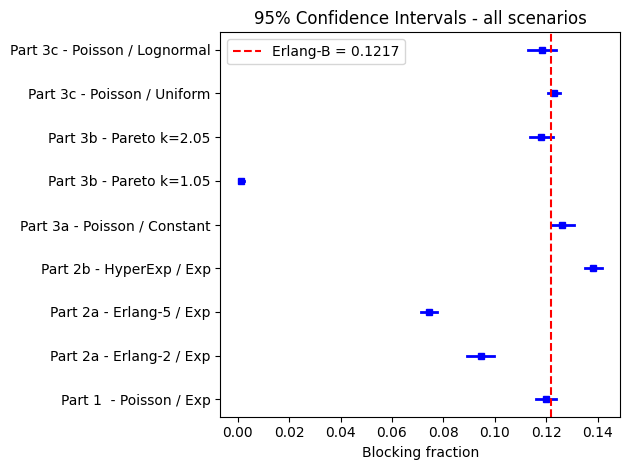

In [774]:
for i, (label, mean_b, lo, hi) in enumerate(all_results):
    plt.plot([lo, hi], [i, i], 'b-', linewidth=2)
    plt.plot(mean_b, i, 'bs', markersize=5)

A = mean_svc / mean_ia
top = A**m / math.factorial(m)
bot = sum(A**i / math.factorial(i) for i in range(m + 1))
plt.axvline(top / bot, color='red', linestyle='--', label='Erlang-B = ' + str(round(top / bot, 4)))
plt.yticks(range(len(all_results)), [r[0] for r in all_results])
plt.xlabel("Blocking fraction")
plt.title("95% Confidence Intervals - all scenarios")
plt.legend()
plt.tight_layout()
plt.show()

# Exercise 5


## Part 1


### Part 1.a


In [775]:
np.random.seed(42)

n = 100
U = np.random.uniform(0, 1, n)
X = np.exp(U)

bar_theta = np.mean(X)
print("Point estimate:", round(bar_theta, 4))

Point estimate: 1.6721


### Part 1.b


In [776]:
alpha = 0.05
z = stats.norm.ppf(1 - alpha / 2)
s = np.std(X, ddof=1)

ci_lower = bar_theta - z * s / np.sqrt(n)
ci_upper = bar_theta + z * s / np.sqrt(n)

print(f"95% CI: ({round(ci_lower, 4)}, {round(ci_upper, 4)})")

95% CI: (1.574, 1.7701)


## Part 2


In [777]:
f_U = np.exp(U)
f_U_anti = np.exp(1 - U)
Y = (f_U + f_U_anti) / 2

print("Mean:", round(np.mean(Y), 4))

Mean: 1.7226


In [778]:
bar_theta_anti = np.mean(Y)
s_anti = np.std(Y, ddof=1)

ci_lower = bar_theta_anti - z * s_anti / np.sqrt(len(Y))
ci_upper = bar_theta_anti + z * s_anti / np.sqrt(len(Y))

print(f"95% CI: ({round(ci_lower, 4)}, {round(ci_upper, 4)})")

95% CI: (1.7103, 1.7349)


## Part 3


In [779]:
Z = U
mu_Z = 0.5

cov_XZ = np.mean(X * Z) - np.mean(X) * np.mean(Z)
var_Z  = np.var(Z, ddof=1)
c = -cov_XZ / var_Z

Y_cv = X + c * (Z - mu_Z)

bar_theta_cv = np.mean(Y_cv)
print("Point estimate:", round(bar_theta_cv, 4))
print("c:", round(c, 4))

Point estimate: 1.7213
c: -1.6515


In [780]:
s_cv = np.std(Y_cv, ddof=1)

ci_lower = bar_theta_cv - z * s_cv / np.sqrt(len(Y_cv))
ci_upper = bar_theta_cv + z * s_cv / np.sqrt(len(Y_cv))

print(f"95% CI: ({round(ci_lower, 4)}, {round(ci_upper, 4)})")
print("Variance:", round(np.std(Y_cv)**2, 6))

95% CI: (1.7091, 1.7335)
Variance: 0.003845


## Part 4


In [781]:
k = 10
n = 100

Y_ss = []

for i in range(n):
    U_strat = (np.arange(k) + np.random.uniform(0, 1, k)) / k
    Y_ss.append(np.mean(np.exp(U_strat)))

Y_ss = np.array(Y_ss)
bar_theta_ss = np.mean(Y_ss)
print("Point estimate:", round(bar_theta_ss, 4))

Point estimate: 1.7176


In [782]:
s_ss = np.std(Y_ss, ddof=1)

ci_lower_ss = bar_theta_ss - z * s_ss / np.sqrt(n)
ci_upper_ss = bar_theta_ss + z * s_ss / np.sqrt(n)

print(f"95% CI: ({round(ci_lower_ss, 4)}, {round(ci_upper_ss, 4)})")

95% CI: (1.7142, 1.721)


## Part 5


In [783]:
m = 10
mean_svc = 8
mean_ia  = 1
n = 10000
reps = 10

np.random.seed(42)

blocking_vals = []
avg_svc_vals  = []

for rep in range(reps):
    free_at   = [0.0] * m
    blocked   = 0
    now       = 0.0
    total_svc = 0.0
    served    = 0

    for _ in range(n):
        u = np.random.random()
        now += -np.log(u) * mean_ia

        u = np.random.random()
        svc = -np.log(u) * mean_svc

        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
            total_svc += svc
            served += 1
        else:
            blocked += 1

    blocking_vals.append(blocked / n)
    avg_svc_vals.append(total_svc / served)

X_sim = np.array(blocking_vals)
Z_sim = np.array(avg_svc_vals)

In [784]:
cov_XZ = np.mean(X_sim * Z_sim) - np.mean(X_sim) * np.mean(Z_sim)
var_Z  = np.var(Z_sim, ddof=1)
c = -cov_XZ / var_Z

Y_cv = X_sim + c * (Z_sim - mean_svc)

mean_cv = np.mean(Y_cv)
s_cv    = np.std(Y_cv, ddof=1)
t_crit  = stats.t.ppf(0.975, df=reps - 1)
margin  = t_crit * s_cv / np.sqrt(reps)

print("Point estimate:", round(mean_cv, 5))
print("95% CI: (", round(mean_cv - margin, 5), ",", round(mean_cv + margin, 5), ")")

Point estimate: 0.12343
95% CI: ( 0.1202 , 0.12667 )


In [785]:
s_plain = np.std(X_sim, ddof=1)
margin_plain = t_crit * s_plain / np.sqrt(reps)

print("CI width without control variates:", round(2 * margin_plain, 5))
print("CI width with control variates:   ", round(2 * margin, 5))

CI width without control variates: 0.01161
CI width with control variates:    0.00647


## Part 6


## Part 7


In [786]:
np.random.seed(42)

n = 10000
a = 2

Z_crude = np.random.normal(0, 1, n)
p_crude = np.mean(Z_crude > a)

print("Crude estimate:", round(p_crude, 6))
print("True value:    ", round(stats.norm.sf(a), 6))

Crude estimate: 0.0237
True value:     0.02275


In [787]:
def importance_sampling(a, sigma2, n):
    sigma = np.sqrt(sigma2)
    Y = np.random.normal(a, sigma, n)
    f_Y = stats.norm.pdf(Y, 0, 1)
    g_Y = stats.norm.pdf(Y, a, sigma)
    weights = (Y > a) * f_Y / g_Y
    return np.mean(weights)

In [788]:
for a in [2, 3, 4, 5]:
    est  = importance_sampling(a, sigma2=1.0, n=1000)
    true = stats.norm.sf(a)
    print("a =", a, "  IS =", round(est, 6), "  true =", round(true, 6))

a = 2   IS = 0.022937   true = 0.02275
a = 3   IS = 0.001347   true = 0.00135
a = 4   IS = 3.2e-05   true = 3.2e-05
a = 5   IS = 0.0   true = 0.0


In [789]:
for n in [100, 500, 1000, 5000, 10000]:
    est = importance_sampling(a=3, sigma2=1.0, n=n)
    print("n =", n, "  IS =", round(est, 6), "  true =", round(stats.norm.sf(3), 6))

n = 100   IS = 0.000509   true = 0.00135
n = 500   IS = 0.001336   true = 0.00135
n = 1000   IS = 0.001361   true = 0.00135
n = 5000   IS = 0.001405   true = 0.00135
n = 10000   IS = 0.001372   true = 0.00135


In [790]:
for sigma2 in [0.5, 1.0, 2.0, 5.0]:
    est = importance_sampling(a=3, sigma2=sigma2, n=1000)
    print("sigma2 =", sigma2, "  IS =", round(est, 6), "  true =", round(stats.norm.sf(3), 6))

sigma2 = 0.5   IS = 0.001269   true = 0.00135
sigma2 = 1.0   IS = 0.001439   true = 0.00135
sigma2 = 2.0   IS = 0.001171   true = 0.00135
sigma2 = 5.0   IS = 0.001141   true = 0.00135


## Part 8


In [791]:
def g_estimate(lam, n):
    U = np.random.uniform(0, 1, n)
    Y = -1 / lam * np.log(1 - U * (1 - np.exp(-lam)))
    g_Y = lam * np.exp(-lam * Y) / (1 - np.exp(-lam))
    weights = np.exp(Y) / g_Y
    return np.mean(weights), np.var(weights)

In [792]:
lam_values = np.linspace(0.01, 5, 500)
variances = []

for lam in lam_values:
    est, var = g_estimate(lam, n=10000)
    variances.append(var)

optimal_lam = lam_values[np.argmin(variances)]
print("Optimal lambda:", round(optimal_lam, 3))

Optimal lambda: 0.01


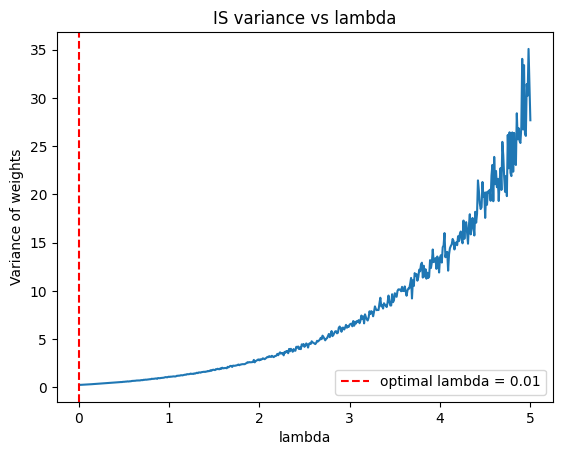

In [793]:
plt.plot(lam_values, variances)
plt.axvline(optimal_lam, color='r', linestyle='--', label='optimal lambda = ' + str(round(optimal_lam, 2)))
plt.xlabel('lambda')
plt.ylabel('Variance of weights')
plt.title('IS variance vs lambda')
plt.legend()
plt.show()

In [794]:
print(f"{'lambda':>8}  {'estimate':>10}  {'variance':>12}")

for lam in [0.5, 1.0, 2.0, 3.0, optimal_lam]:
    est, var = g_estimate(lam, n=10000)
    print(f"{lam:>8.3f}  {est:>10.6f}  {var:>12.8f}")

print("True value:", round(np.e - 1, 6))

  lambda    estimate      variance
   0.500    1.708755    0.56066698
   1.000    1.723156    1.07956696
   2.000    1.701858    2.79234869
   3.000    1.726864    6.38056647
   0.010    1.719703    0.24582503
True value: 1.718282


## Part 9


# Exercise 6


## Part 1


In [795]:
np.random.seed(42)

A = 8
m = 10
n = 10000
burn_in = 1000

def g(i):
    if i < 0 or i > m:
        return 0.0
    result = 1.0
    for k in range(1, i + 1):
        result *= A / k
    return result

state = 0
samples = []

for _ in range(n + burn_in):
    u = np.random.random()
    if u < 0.5:
        proposal = state + 1
    else:
        proposal = state - 1

    if proposal < 0 or proposal > m:
        alpha = 0.0
    else:
        alpha = min(1.0, g(proposal) / g(state))

    if np.random.random() < alpha:
        state = proposal

    samples.append(state)

samples = samples[burn_in:]

In [796]:
total = sum(g(i) for i in range(m + 1))
exact = [g(i) / total for i in range(m + 1)]

observed = [samples.count(i) for i in range(m + 1)]

print(f"{'State':>6} {'Observed':>10} {'Expected':>10}")
print("-" * 30)
for i in range(m + 1):
    print(f"{i:>6} {observed[i]:>10} {round(exact[i] * n, 2):>10}")

 State   Observed   Expected
------------------------------
     0          4       4.11
     1         22      32.89
     2        105     131.57
     3        361     350.86
     4        762     701.72
     5       1151    1122.75
     6       1503     1497.0
     7       1686    1710.86
     8       1712    1710.86
     9       1531    1520.76
    10       1163    1216.61


In [797]:
chi2_stat = 0.0
for i in range(m + 1):
    expected_count = exact[i] * n
    chi2_stat += (observed[i] - expected_count)**2 / expected_count

df = m
critical = stats.chi2.ppf(0.95, df=df)

print("Chi-square statistic:", round(chi2_stat, 4))
print("Critical value (df=" + str(df) + ", 0.95):", round(critical, 4))

if chi2_stat < critical:
    print("Do not reject: samples match truncated Poisson distribution")
else:
    print("Reject: samples do not match")

Chi-square statistic: 17.9765
Critical value (df=10, 0.95): 18.307
Do not reject: samples match truncated Poisson distribution


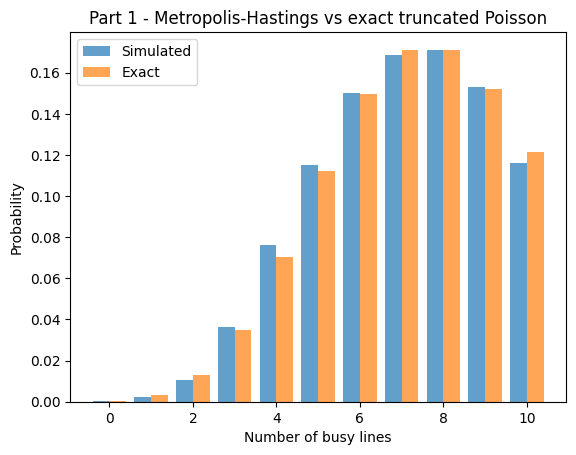

In [798]:
x_vals = list(range(m + 1))

plt.bar([x - 0.2 for x in x_vals], [o / n for o in observed], width=0.4, label="Simulated", alpha=0.7)
plt.bar([x + 0.2 for x in x_vals], exact, width=0.4, label="Exact", alpha=0.7)
plt.xlabel("Number of busy lines")
plt.ylabel("Probability")
plt.title("Part 1 - Metropolis-Hastings vs exact truncated Poisson")
plt.legend()
plt.show()

## Part 2


In [799]:
np.random.seed(42)

A1 = 4
A2 = 4
m = 10
n = 20000
burn_in = 2000

def g2(i, j):
    if i < 0 or j < 0 or i + j > m:
        return 0.0
    val_i = 1.0
    for k in range(1, i + 1):
        val_i *= A1 / k
    val_j = 1.0
    for k in range(1, j + 1):
        val_j *= A2 / k
    return val_i * val_j

moves = [(1, 0), (-1, 0), (0, 1), (0, -1)]

si, sj = 0, 0
samples2d = []

for _ in range(n + burn_in):
    di, dj = moves[int(np.random.random() * 4)]
    pi, pj = si + di, sj + dj

    g_cur = g2(si, sj)
    g_prop = g2(pi, pj)

    if g_cur == 0.0:
        alpha = 1.0
    else:
        alpha = min(1.0, g_prop / g_cur)

    if np.random.random() < alpha:
        si, sj = pi, pj

    samples2d.append((si, sj))

samples2d = samples2d[burn_in:]

In [800]:
total2d = sum(g2(i, j) for i in range(m + 1) for j in range(m + 1) if i + j <= m)
states2d = [(i, j) for i in range(m + 1) for j in range(m + 1) if i + j <= m]

observed2d = {}
for s in samples2d:
    observed2d[s] = observed2d.get(s, 0) + 1

chi2_stat = 0.0
for state in states2d:
    expected_count = g2(*state) / total2d * n
    obs_count = observed2d.get(state, 0)
    if expected_count > 0:
        chi2_stat += (obs_count - expected_count)**2 / expected_count

df = len(states2d) - 1
critical = stats.chi2.ppf(0.95, df=df)

print("Direct MH chi-square:", round(chi2_stat, 4))
print("Critical value (df=" + str(df) + "):", round(critical, 4))

if chi2_stat < critical:
    print("Do not reject: good fit")
else:
    print("Reject")

Direct MH chi-square: 423.3448
Critical value (df=65): 84.8206
Reject


### Coordinatewise MH


In [801]:
np.random.seed(42)

si, sj = 0, 0
samples_cw = []

for _ in range(n + burn_in):
    if np.random.random() < 0.5:
        di = 1 if np.random.random() < 0.5 else -1
        pi, pj = si + di, sj
    else:
        dj = 1 if np.random.random() < 0.5 else -1
        pi, pj = si, sj + dj

    g_cur = g2(si, sj)
    g_prop = g2(pi, pj)

    if g_cur == 0.0:
        alpha = 1.0
    else:
        alpha = min(1.0, g_prop / g_cur)

    if np.random.random() < alpha:
        si, sj = pi, pj

    samples_cw.append((si, sj))

samples_cw = samples_cw[burn_in:]

observed_cw = {}
for s in samples_cw:
    observed_cw[s] = observed_cw.get(s, 0) + 1

chi2_cw = 0.0
for state in states2d:
    expected_count = g2(*state) / total2d * n
    obs_count = observed_cw.get(state, 0)
    if expected_count > 0:
        chi2_cw += (obs_count - expected_count)**2 / expected_count

print("Coordinatewise MH chi-square:", round(chi2_cw, 4))
print("Critical value:", round(critical, 4))

if chi2_cw < critical:
    print("Do not reject: good fit")
else:
    print("Reject")

Coordinatewise MH chi-square: 189.965
Critical value: 84.8206
Reject


### Gibbs sampling


In [802]:
np.random.seed(42)

si, sj = 0, 0
samples_gibbs = []

for _ in range(n + burn_in):
    if np.random.random() < 0.5:
        max_i = m - sj
        weights_i = [g2(i, sj) for i in range(max_i + 1)]
        total_i = sum(weights_i)
        probs_i = [w / total_i for w in weights_i]
        u = np.random.random()
        cumulative = 0.0
        for i, p in enumerate(probs_i):
            cumulative += p
            if u < cumulative:
                si = i
                break
    else:
        max_j = m - si
        weights_j = [g2(si, j) for j in range(max_j + 1)]
        total_j = sum(weights_j)
        probs_j = [w / total_j for w in weights_j]
        u = np.random.random()
        cumulative = 0.0
        for j, p in enumerate(probs_j):
            cumulative += p
            if u < cumulative:
                sj = j
                break

    samples_gibbs.append((si, sj))

samples_gibbs = samples_gibbs[burn_in:]

observed_gibbs = {}
for s in samples_gibbs:
    observed_gibbs[s] = observed_gibbs.get(s, 0) + 1

chi2_gibbs = 0.0
for state in states2d:
    expected_count = g2(*state) / total2d * n
    obs_count = observed_gibbs.get(state, 0)
    if expected_count > 0:
        chi2_gibbs += (obs_count - expected_count)**2 / expected_count

print("Gibbs sampling chi-square:", round(chi2_gibbs, 4))
print("Critical value:", round(critical, 4))

if chi2_gibbs < critical:
    print("Do not reject: good fit")
else:
    print("Reject")

Gibbs sampling chi-square: 124.3526
Critical value: 84.8206
Reject


## Part 3


### Part 3.a


In [803]:
np.random.seed(42)

rho = 0.5

U1 = np.random.random()
U2 = np.random.random()
z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
U3 = np.random.random()
U4 = np.random.random()
z2_ind = np.sqrt(-2 * np.log(U3)) * np.cos(2 * np.pi * U4)
z2 = rho * z1 + np.sqrt(1 - rho**2) * z2_ind

xi    = z1
gamma = z2
theta = np.exp(xi)
psi   = np.exp(gamma)

print("xi:    ", round(xi, 4))
print("gamma: ", round(gamma, 4))
print("theta: ", round(theta, 4))
print("psi:   ", round(psi, 4))

xi:     1.3348
gamma:  0.1106
theta:  3.7993
psi:    1.1169


### Part 3.b


In [804]:
n_obs = 10

X_obs = []
for _ in range(n_obs):
    U1 = np.random.random()
    U2 = np.random.random()
    z = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    X_obs.append(theta + np.sqrt(psi) * z)

print("Observations:", [round(x, 4) for x in X_obs])
print("Sample mean: ", round(sum(X_obs) / n_obs, 4))

Observations: [np.float64(4.9338), np.float64(5.4806), np.float64(3.5216), np.float64(6.6921), np.float64(3.9493), np.float64(4.5922), np.float64(2.1886), np.float64(3.4485), np.float64(4.4696), np.float64(2.6922)]
Sample mean:  4.1968


### Part 3.c


In [805]:
x_bar = sum(X_obs) / n_obs
s2    = sum((x - x_bar)**2 for x in X_obs) / n_obs

def log_prior(th, ps):
    if th <= 0 or ps <= 0:
        return -np.inf
    lx = np.log(th)
    ly = np.log(ps)
    return -1 / (2 * (1 - rho**2)) * (lx**2 - 2 * rho * lx * ly + ly**2) - np.log(th) - np.log(ps)

def log_likelihood(th, ps):
    if th <= 0 or ps <= 0:
        return -np.inf
    return -n_obs / 2 * np.log(ps) - n_obs / (2 * ps) * (s2 + (x_bar - th)**2)

def log_posterior(th, ps):
    return log_prior(th, ps) + log_likelihood(th, ps)

### Part 3.d


In [806]:
np.random.seed(42)

n_mcmc   = 20000
burn_in_mcmc = 2000
step     = 0.3

th_cur = 1.0
ps_cur = 1.0
theta_samples = []
psi_samples   = []

for _ in range(n_mcmc + burn_in_mcmc):
    U1 = np.random.random()
    U2 = np.random.random()
    z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    U3 = np.random.random()
    U4 = np.random.random()
    z2 = np.sqrt(-2 * np.log(U3)) * np.cos(2 * np.pi * U4)

    th_prop = th_cur * np.exp(step * z1)
    ps_prop = ps_cur * np.exp(step * z2)

    log_alpha = log_posterior(th_prop, ps_prop) - log_posterior(th_cur, ps_cur)
    log_alpha += np.log(th_prop) + np.log(ps_prop) - np.log(th_cur) - np.log(ps_cur)

    if np.log(np.random.random()) < log_alpha:
        th_cur = th_prop
        ps_cur = ps_prop

    theta_samples.append(th_cur)
    psi_samples.append(ps_cur)

theta_samples = theta_samples[burn_in_mcmc:]
psi_samples   = psi_samples[burn_in_mcmc:]

print("Posterior mean theta:", round(sum(theta_samples) / len(theta_samples), 4))
print("Posterior mean psi:  ", round(sum(psi_samples)   / len(psi_samples),   4))
print("True theta:", round(theta, 4), "  True psi:", round(psi, 4))

Posterior mean theta: 4.0697
Posterior mean psi:   2.1324
True theta: 3.7993   True psi: 1.1169


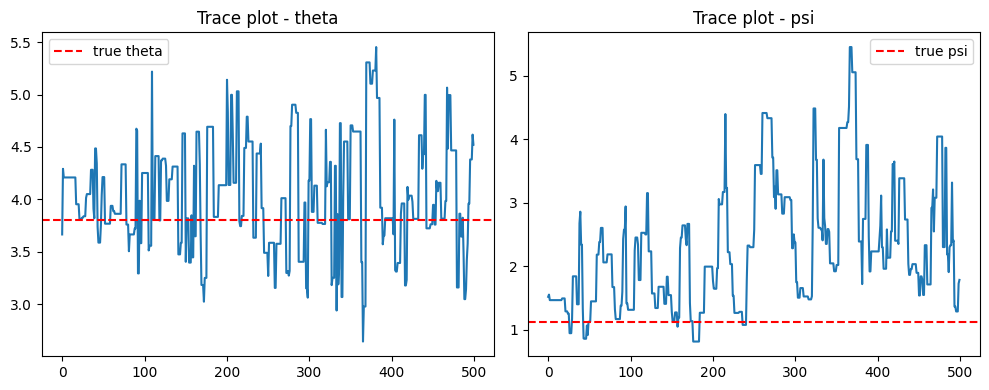

In [807]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(theta_samples[:500])
plt.axhline(theta, color='red', linestyle='--', label='true theta')
plt.title("Trace plot - theta")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(psi_samples[:500])
plt.axhline(psi, color='red', linestyle='--', label='true psi')
plt.title("Trace plot - psi")
plt.legend()
plt.tight_layout()
plt.show()

### Part 3.e


In [808]:
for n_obs2 in [100, 1000]:
    np.random.seed(42)

    X_obs2 = []
    for _ in range(n_obs2):
        U1 = np.random.random()
        U2 = np.random.random()
        z = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
        X_obs2.append(theta + np.sqrt(psi) * z)

    x_bar2 = sum(X_obs2) / n_obs2
    s2_2   = sum((x - x_bar2)**2 for x in X_obs2) / n_obs2

    def log_lik2(th, ps):
        if th <= 0 or ps <= 0:
            return -np.inf
        return -n_obs2 / 2 * np.log(ps) - n_obs2 / (2 * ps) * (s2_2 + (x_bar2 - th)**2)

    th_cur2 = 1.0
    ps_cur2 = 1.0
    th_samp2 = []
    ps_samp2 = []

    for _ in range(n_mcmc + burn_in_mcmc):
        U1 = np.random.random()
        U2 = np.random.random()
        z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
        U3 = np.random.random()
        U4 = np.random.random()
        z2 = np.sqrt(-2 * np.log(U3)) * np.cos(2 * np.pi * U4)

        th_prop2 = th_cur2 * np.exp(step * z1)
        ps_prop2 = ps_cur2 * np.exp(step * z2)

        log_a = log_prior(th_prop2, ps_prop2) + log_lik2(th_prop2, ps_prop2)
        log_a -= log_prior(th_cur2, ps_cur2) + log_lik2(th_cur2, ps_cur2)
        log_a += np.log(th_prop2) + np.log(ps_prop2) - np.log(th_cur2) - np.log(ps_cur2)

        if np.log(np.random.random()) < log_a:
            th_cur2 = th_prop2
            ps_cur2 = ps_prop2

        th_samp2.append(th_cur2)
        ps_samp2.append(ps_cur2)

    th_samp2 = th_samp2[burn_in_mcmc:]
    ps_samp2 = ps_samp2[burn_in_mcmc:]

    print("n =", n_obs2)
    print("  Posterior mean theta:", round(sum(th_samp2) / len(th_samp2), 4), "  true:", round(theta, 4))
    print("  Posterior mean psi:  ", round(sum(ps_samp2) / len(ps_samp2), 4), "  true:", round(psi, 4))

n = 100
  Posterior mean theta: 3.8282   true: 3.7993
  Posterior mean psi:   1.3441   true: 1.1169
n = 1000
  Posterior mean theta: 3.819   true: 3.7993
  Posterior mean psi:   1.2248   true: 1.1169


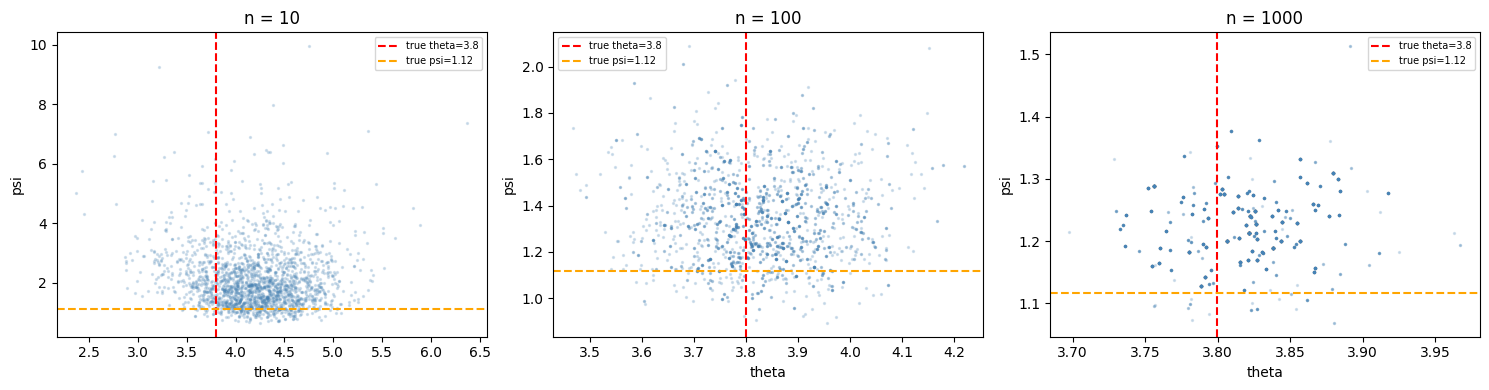

In [809]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n_obs2 in zip(axes, [10, 100, 1000]):
    np.random.seed(42)
    X_obs2 = []
    for _ in range(n_obs2):
        U1 = np.random.random()
        U2 = np.random.random()
        z = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
        X_obs2.append(theta + np.sqrt(psi) * z)
    x_bar2 = sum(X_obs2) / n_obs2
    s2_2 = sum((x - x_bar2)**2 for x in X_obs2) / n_obs2

    def log_lik_plot(th, ps):
        if th <= 0 or ps <= 0:
            return -np.inf
        return -n_obs2 / 2 * np.log(ps) - n_obs2 / (2 * ps) * (s2_2 + (x_bar2 - th)**2)

    th_p = 1.0
    ps_p = 1.0
    th_plot = []
    ps_plot = []

    for _ in range(n_mcmc + burn_in_mcmc):
        U1 = np.random.random()
        U2 = np.random.random()
        z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
        U3 = np.random.random()
        U4 = np.random.random()
        z2 = np.sqrt(-2 * np.log(U3)) * np.cos(2 * np.pi * U4)
        th_prop = th_p * np.exp(step * z1)
        ps_prop = ps_p * np.exp(step * z2)
        log_a = log_prior(th_prop, ps_prop) + log_lik_plot(th_prop, ps_prop)
        log_a -= log_prior(th_p, ps_p) + log_lik_plot(th_p, ps_p)
        log_a += np.log(th_prop) + np.log(ps_prop) - np.log(th_p) - np.log(ps_p)
        if np.log(np.random.random()) < log_a:
            th_p = th_prop
            ps_p = ps_prop
        th_plot.append(th_p)
        ps_plot.append(ps_p)

    th_plot = th_plot[burn_in_mcmc:]
    ps_plot = ps_plot[burn_in_mcmc:]

    ax.scatter(th_plot[::10], ps_plot[::10], alpha=0.2, s=2, color='steelblue')
    ax.axvline(theta, color='red', linestyle='--', label='true theta=' + str(round(theta, 2)))
    ax.axhline(psi, color='orange', linestyle='--', label='true psi=' + str(round(psi, 2)))
    ax.set_title("n = " + str(n_obs2))
    ax.set_xlabel("theta")
    ax.set_ylabel("psi")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Exercise 7


## Part 1


In [810]:
np.random.seed(42)

n_cities = 20

angles = [2 * np.pi * i / n_cities for i in range(n_cities)]
points = [[np.cos(a), np.sin(a)] for a in angles]

def route_cost(pts, route):
    total = 0.0
    for i in range(len(route)):
        a = pts[route[i]]
        b = pts[route[(i + 1) % len(route)]]
        total += ((a[0] - b[0])**2 + (a[1] - b[1])**2)**0.5
    return total

route = list(range(n_cities))
np.random.shuffle(route)

best_route = route[:]
best_cost = route_cost(points, best_route)
history = []

for k in range(50000):
    i = int(np.random.random() * n_cities)
    j = int(np.random.random() * n_cities)
    while j == i:
        j = int(np.random.random() * n_cities)

    proposal = route[:]
    proposal[i], proposal[j] = proposal[j], proposal[i]

    current_cost = route_cost(points, route)
    new_cost = route_cost(points, proposal)

    temperature = 2 / (1 + k)**0.5
    diff = new_cost - current_cost

    if diff <= 0 or np.random.random() < np.exp(-diff / temperature):
        route = proposal[:]

    if route_cost(points, route) < best_cost:
        best_route = route[:]
        best_cost = route_cost(points, best_route)

    history.append(best_cost)

print("Best route:", best_route)
print("Best cost:", round(best_cost, 4))
print("Circle order cost:", round(route_cost(points, list(range(n_cities))), 4))

Best route: [12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 19, 18, 17, 16, 15, 14, 13]
Best cost: 6.2574
Circle order cost: 6.2574


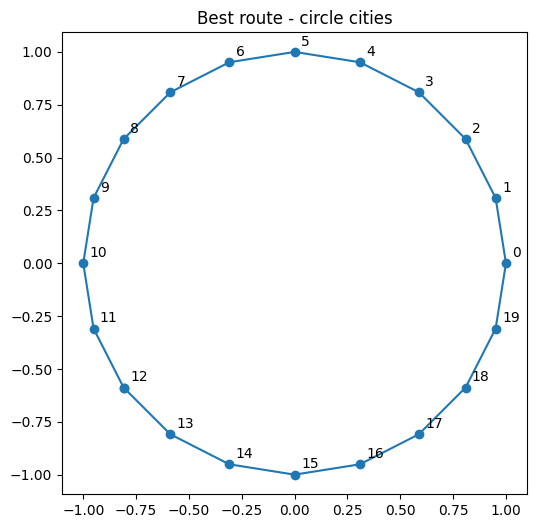

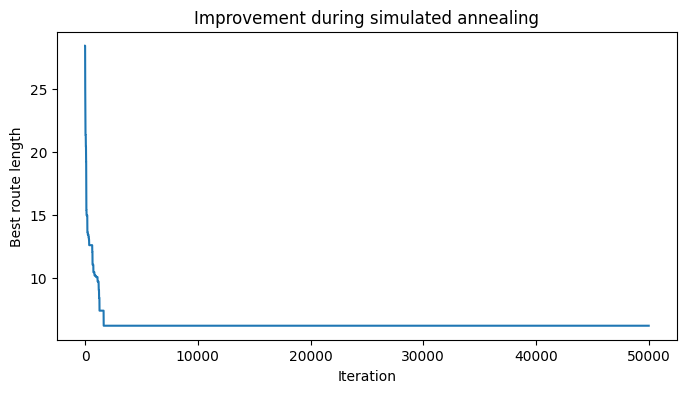

In [811]:
closed = best_route + [best_route[0]]

plt.figure(figsize=(6, 6))
plt.plot([points[i][0] for i in closed], [points[i][1] for i in closed], 'o-')
for i in range(n_cities):
    plt.text(points[i][0] + 0.03, points[i][1] + 0.03, str(i))
plt.axis('equal')
plt.title("Best route - circle cities")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Best route length")
plt.title("Improvement during simulated annealing")
plt.show()

## Part 2


In [812]:
np.random.seed(42)

cost_matrix = np.loadtxt("cost.csv", delimiter=",")

n_c = len(cost_matrix)

def matrix_cost(mat, route):
    total = 0.0
    for i in range(len(route)):
        total += mat[route[i]][route[(i + 1) % len(route)]]
    return total

route = list(range(n_c))
np.random.shuffle(route)

best_route = route[:]
best_cost = matrix_cost(cost_matrix, best_route)

for k in range(50000):
    i = int(np.random.random() * n_c)
    j = int(np.random.random() * n_c)
    while j == i:
        j = int(np.random.random() * n_c)

    proposal = route[:]
    proposal[i], proposal[j] = proposal[j], proposal[i]

    current_cost = matrix_cost(cost_matrix, route)
    new_cost = matrix_cost(cost_matrix, proposal)

    temperature = 10 / (1 + k)**0.5
    diff = new_cost - current_cost

    if diff <= 0 or np.random.random() < np.exp(-diff / temperature):
        route = proposal[:]

    if matrix_cost(cost_matrix, route) < best_cost:
        best_route = route[:]
        best_cost = matrix_cost(cost_matrix, best_route)

print("Best route:", best_route)
print("Best cost:", round(best_cost, 1))

Best route: [12, 0, 3, 18, 14, 2, 10, 19, 6, 17, 16, 9, 15, 7, 4, 11, 5, 13, 8, 1]
Best cost: 1548.0


# Exercise 8


## Part 1 - Book Exercise 13


### Part 1.a


In [813]:
sample_13 = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]
n = len(sample_13)
a = -5
b = 5
B = 10000

sample_mean = sum(sample_13) / n

boot_diffs = []
np.random.seed(42)

for _ in range(B):
    boot = []
    for _ in range(n):
        idx = int(np.random.random() * n)
        boot.append(sample_13[idx])
    boot_mean = sum(boot) / n
    boot_diffs.append(boot_mean - sample_mean)

count_in = sum(1 for d in boot_diffs if a < d < b)
p_hat = count_in / B

print("Sample mean:", round(sample_mean, 4))
print("Bootstrap estimate of p:", round(p_hat, 4))

Sample mean: 76.7
Bootstrap estimate of p: 0.7592


### Part 1.b


In [814]:
np.random.seed(42)

sample_13 = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]
n = len(sample_13)
a = -5
b = 5
B = 10000

sample_mean = sum(sample_13) / n
bootstrap_diffs = []

for _ in range(B):
    boot = []
    for _ in range(n):
        idx = int(np.random.random() * n)
        boot.append(sample_13[idx])
    bootstrap_diffs.append(sum(boot) / n - sample_mean)

count_in = 0
for d in bootstrap_diffs:
    if a < d < b:
        count_in += 1

p_estimate = count_in / B

print("Sample mean:", round(sample_mean, 4))
print("Bootstrap estimate of p:", round(p_estimate, 4))

Sample mean: 76.7
Bootstrap estimate of p: 0.7592


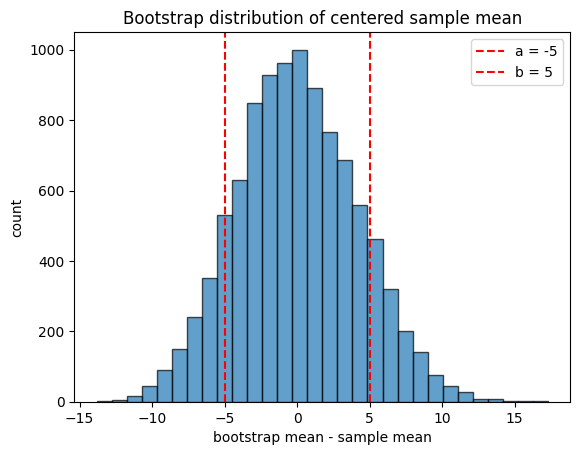

In [815]:
plt.hist(bootstrap_diffs, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(a, color='red', linestyle='--', label='a = -5')
plt.axvline(b, color='red', linestyle='--', label='b = 5')
plt.xlabel("bootstrap mean - sample mean")
plt.ylabel("count")
plt.title("Bootstrap distribution of centered sample mean")
plt.legend()
plt.show()

## Part 2 - Book Exercise 15


In [816]:
np.random.seed(42)

sample_15 = [5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8]
n = len(sample_15)
B = 10000

bootstrap_variances = []

for _ in range(B):
    boot = []
    for _ in range(n):
        idx = int(np.random.random() * n)
        boot.append(sample_15[idx])
    boot_mean = sum(boot) / n
    boot_var = sum((x - boot_mean)**2 for x in boot) / (n - 1)
    bootstrap_variances.append(boot_var)

boot_mean_var = sum(bootstrap_variances) / B
variance_of_s2 = sum((v - boot_mean_var)**2 for v in bootstrap_variances) / (B - 1)

sample_mean_15 = sum(sample_15) / n
s2 = sum((x - sample_mean_15)**2 for x in sample_15) / (n - 1)

print("Observed sample variance S^2:", round(s2, 4))
print("Bootstrap estimate of Var(S^2):", round(variance_of_s2, 4))

Observed sample variance S^2: 34.3143
Bootstrap estimate of Var(S^2): 58.1795


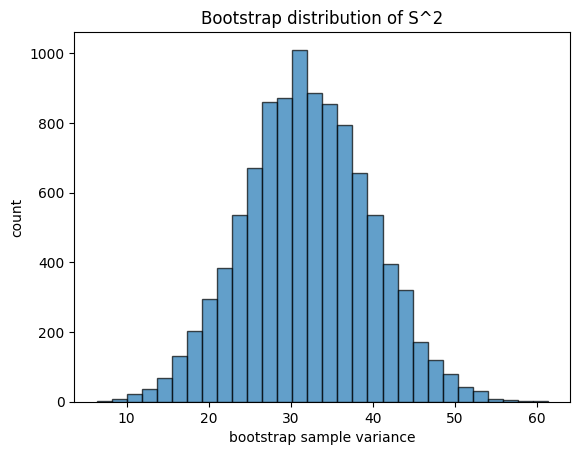

In [817]:
plt.hist(bootstrap_variances, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("bootstrap sample variance")
plt.ylabel("count")
plt.title("Bootstrap distribution of S^2")
plt.show()

## Part 3


In [818]:
np.random.seed(42)

beta = 1
shape = 1.05
n = 200
B = 100

pareto_sample = []
for _ in range(n):
    u = np.random.random()
    pareto_sample.append(beta * u**(-1.0 / shape))

sorted_sample = sorted(pareto_sample)
sample_median = sorted_sample[n // 2] if n % 2 == 1 else (sorted_sample[n // 2 - 1] + sorted_sample[n // 2]) / 2
sample_mean = sum(pareto_sample) / n

print("Sample mean:", round(sample_mean, 4))
print("Sample median:", round(sample_median, 4))

Sample mean: 5.4722
Sample median: 1.9556


In [819]:
boot_medians = []
boot_means = []

for _ in range(B):
    boot = []
    for _ in range(n):
        idx = int(np.random.random() * n)
        boot.append(pareto_sample[idx])

    boot_sorted = sorted(boot)
    if n % 2 == 1:
        boot_med = boot_sorted[n // 2]
    else:
        boot_med = (boot_sorted[n // 2 - 1] + boot_sorted[n // 2]) / 2

    boot_medians.append(boot_med)
    boot_means.append(sum(boot) / n)

mean_of_means = sum(boot_means) / B
mean_of_medians = sum(boot_medians) / B

var_of_mean = sum((x - mean_of_means)**2 for x in boot_means) / (B - 1)
var_of_median = sum((x - mean_of_medians)**2 for x in boot_medians) / (B - 1)

print("Bootstrap variance of the mean:  ", round(var_of_mean, 4))
print("Bootstrap variance of the median:", round(var_of_median, 4))

if var_of_median < var_of_mean:
    print("The median is more precise than the mean")
else:
    print("The mean is more precise than the median")

Bootstrap variance of the mean:   0.8694
Bootstrap variance of the median: 0.0515
The median is more precise than the mean


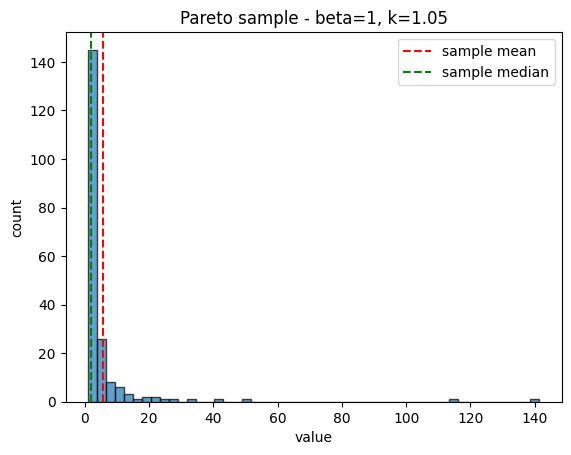

In [820]:
plt.hist(pareto_sample, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(sample_mean, color='red', linestyle='--', label='sample mean')
plt.axvline(sample_median, color='green', linestyle='--', label='sample median')
plt.xlabel("value")
plt.ylabel("count")
plt.title("Pareto sample - beta=1, k=1.05")
plt.legend()
plt.show()